# SHBT 261 AI in Medicine Mini Project 2

**Harvard University**\
**Spring 2026**\
**Instructors**: Mengyu Wang and Tobias Elze\
**Name**: Cindy Sun

<hr style="height:2pt">

### ⚠️ Note Before Running the Code

Please make sure you have a `data` folder set up that contains the following files and directories:

- `VOCtrainval_06-Nov-2007/`  
- `VOCtest_06-Nov-2007/`  
- `PASCAL_VOC/`  
- `pascal-voc-2007.zip` (the original dataset downloaded from Kaggle https://www.kaggle.com/datasets/zaraks/pascal-voc-2007)

In this project, the code was run using **Google Colab** with Google Drive mounted.  
If you are using the same setup, make sure your file paths correctly point to the location of your `data` fol
der in Drive (e.g., `/content/drive/MyDrive/...`).  

Incorrect paths may cause the code to fail when loading the dataset.

# 1. Imports & Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import subprocess, sys

# Install SAM 2 from source
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "git+https://github.com/facebookresearch/sam2.git"],
    capture_output=True, text=True
)
print(result.stdout[-3000:] if result.stdout else "No stdout")
print(result.stderr[-2000:] if result.stderr else "No stderr")
print("Return code:", result.returncode)

kages (from torch>=2.5.1->SAM-2==1.0) (11.7.3.90)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 20.1 MB/s eta 0:00:00
  Created wheel for SAM-2: filename=sam_2-1.0-cp312-cp312-linux_x86_64.whl size=183669 sha256=ff73fd39458e799f2c64c205809b73297eeafaa94b94060b21e4210072c4181f
  Stored in directory: /tmp/pip-ephem-wheel-cache-04cgtep5/wheels/25/a3/8a/abd69dc6a6926b5e75c24810afac36c7b49b5c0f8a100147d6
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=094d3986804602e393baae7492649974bd2d9cc5e78c682cb3fb80eab51f8f74
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built SAM-2 iopath

  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam2.git /tmp/pip-req-build-u295kzgz

Return code: 0


In [3]:
# ── Standard Library ────────────────────────────────────────────────────────
import os
import json
import subprocess
import urllib.request

# ── Numerical & Visualization ────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from tqdm import tqdm

# ── PyTorch Core ─────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# ── TorchVision — Transforms, Datasets, Models ───────────────────────────────
from torchvision import transforms
from torchvision.transforms import v2
from torchvision.datasets import VOCSegmentation
from torchvision.models.segmentation import (
    deeplabv3_resnet50,
    DeepLabV3_ResNet50_Weights,
)

# ── SAM 2 ────────────────────────────────────────────────────────────────────
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

# ── Metric Calculation ───────────────────────────────────────────────────────
from scipy.spatial import cKDTree
from scipy.spatial.distance import directed_hausdorff

# ── Device Setup ─────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("All imports OK ✓")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"Device  : {device}")

All imports OK ✓
PyTorch : 2.10.0+cu128
CUDA    : True
Device  : cuda


# 2. Paths & Config

In [4]:
# ── Paths ──────────────────────────────────────────────────────────────────
notebook_path = '/content/drive/MyDrive/Colab Notebooks/SHBT261_miniproj2/shbt261_cindysun_mini_proj2.ipynb' # this is my personal path
base_path     = os.path.dirname(notebook_path)
data_path     = os.path.join(base_path, 'data')
trainval_root = os.path.join(data_path, 'VOCtrainval_06-Nov-2007')

for d in [base_path, data_path]:
    os.makedirs(d, exist_ok=True)

print("Base path :", base_path)
print("Data path :", data_path)

# ── Config ──────────────────────────────────────────────────────────────────
IMG_SIZE   = 256
BATCH_SIZE = 4
NUM_EPOCHS = 10
LR         = 1e-3
NUM_CLASSES = 21
IGNORE_INDEX = 255

Base path : /content/drive/MyDrive/Colab Notebooks/SHBT261_miniproj2
Data path : /content/drive/MyDrive/Colab Notebooks/SHBT261_miniproj2/data


# 3. Dataset & DataLoader

Copied from instructions.

Number of classes: 21
Classes: ['background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']
Pascal VOC 2007 Class Mapping:
 0  background
 1  aeroplane
 2  bicycle
 3  bird
 4  boat
 5  bottle
 6  bus
 7  car
 8  cat
 9  chair
10  cow
11  diningtable
12  dog
13  horse
14  motorbike
15  person
16  pottedplant
17  sheep
18  sofa
19  train
20  tvmonitor
Train samples: 209
Validation samples: 213


Image batch shape: torch.Size([4, 3, 256, 256])
Mask batch shape: torch.Size([4, 1, 256, 256])


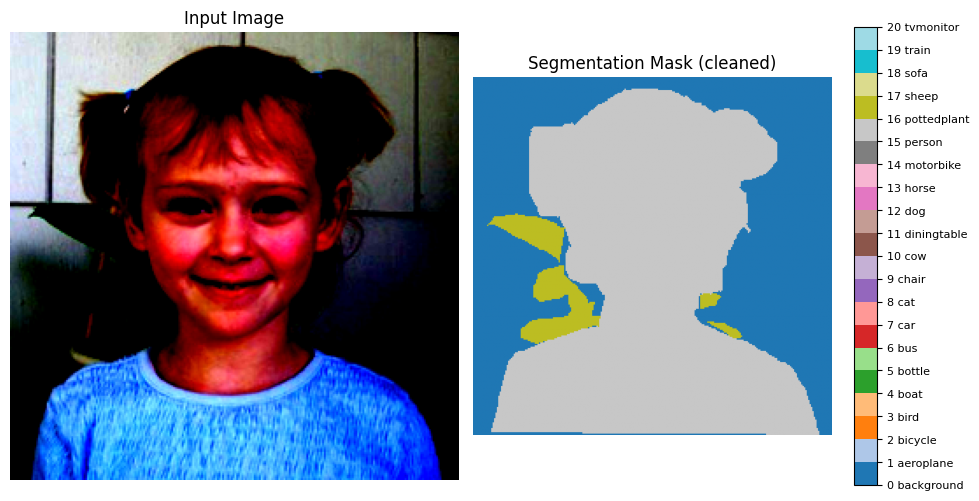

Classes in this mask: [  0  15  16 255]


In [5]:
# load and explore the dataset
# -*- coding: utf-8 -*-
"""
Created on Mon Oct 20 09:17:22 2025

@author: mohae
"""

# -------------------------
# 1. Define the 21 classes
# -------------------------
VOC_CLASSES = [
    "background", "aeroplane", "bicycle", "bird", "boat", "bottle", "bus",
    "car", "cat", "chair", "cow", "diningtable", "dog", "horse", "motorbike",
    "person", "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]
NUM_CLASSES = len(VOC_CLASSES)
print("Number of classes:", NUM_CLASSES)
print("Classes:", VOC_CLASSES)


# ---------------------------------------
# Class mapping dictionary
# ---------------------------------------
class_mapping = {i: cls for i, cls in enumerate(VOC_CLASSES)}

print("Pascal VOC 2007 Class Mapping:")
for idx, name in class_mapping.items():
    print(f"{idx:2d}  {name}")


# -----------------------------------
# 2. Define transforms for the images
# -----------------------------------
transform_img = transforms.Compose([
    transforms.Resize((256, 256)),          # resize for speed
    transforms.ToTensor(),                  # convert to tensor (C,H,W)
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),  # NOTE: I have added this for U-Net modeling
])

transform_target = transforms.Compose([
    transforms.Resize((256, 256)),          # resize mask too
    transforms.PILToTensor()                # keep as tensor (H,W)
])

# --------------------------------------
# 3. Load the Pascal VOC 2007 Segmentation Dataset
# --------------------------------------
train_dataset = VOCSegmentation(
    root=trainval_root,
    year="2007",
    image_set="train",
    download=False,
    transform=transform_img,
    target_transform=transform_target
)

val_dataset = VOCSegmentation(
    root=trainval_root,
    year="2007",
    image_set="val",
    download=False,
    transform=transform_img,
    target_transform=transform_target
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

# -------------------------
# 4. Create DataLoaders
# -------------------------
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)


# ---------------------------------------
# 5. Inspect a single batch (inputs/outputs)
# ---------------------------------------
images, masks = next(iter(train_loader))
print("Image batch shape:", images.shape)   # (B, 3, 256, 256)
print("Mask batch shape:", masks.shape)     # (B, 1, 256, 256)

# ---------------------------------------
# 6. Visualize one image and mask
# ---------------------------------------
def show_sample(img, mask):
    img = img.permute(1, 2, 0).numpy()        # C,H,W -> H,W,C
    mask = mask.squeeze().numpy().copy()       # 1,H,W -> H,W

    # Clean mask: convert all values > 20 (like 255) to 0 for visualization
    mask[mask > 20] = 0

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    seg_map = plt.imshow(mask, cmap="tab20", vmin=0, vmax=20)
    plt.title("Segmentation Mask (cleaned)")
    plt.axis("off")

    # Custom colorbar with class numbers and names
    cbar = plt.colorbar(seg_map, ticks=range(21))
    tick_labels = [f"{i} {VOC_CLASSES[i]}" for i in range(21)]
    cbar.ax.set_yticklabels(tick_labels)
    cbar.ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.show()

# Show first sample
show_sample(images[0], masks[0])
print("Classes in this mask:", np.unique(masks[0].numpy()))

# 5. Metric Functions

In [6]:
def compute_metrics(preds, masks, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX):
    """
    Compute Dice, mIoU, Pixel Accuracy, Per-class IoU and Accuracy.
    preds: (N, H, W) torch tensor
    masks: (N, H, W) torch tensor
    """
    preds = preds.numpy()
    masks = masks.numpy()

    valid = masks != ignore_index

    # Pixel Accuracy
    pixel_acc = (preds[valid] == masks[valid]).mean()

    per_class_iou, per_class_dice, per_class_acc = [], [], []

    for cls in range(num_classes):
        pred_cls = (preds == cls) & valid
        mask_cls = (masks == cls) & valid

        tp = (pred_cls & mask_cls).sum()
        fp = (pred_cls & ~mask_cls).sum()
        fn = (~pred_cls & mask_cls).sum()
        tn = (~pred_cls & ~mask_cls & valid).sum()

        total_valid = valid.sum()

        per_class_iou.append(tp / (tp + fp + fn + 1e-6))
        per_class_dice.append(2 * tp / (2 * tp + fp + fn + 1e-6))
        per_class_acc.append((tp + tn) / (total_valid + 1e-6) if total_valid > 0 else float('nan'))

    return {
        'pixel_acc':      pixel_acc,
        'mIoU':           np.nanmean(per_class_iou),
        'mDice':          np.nanmean(per_class_dice),
        'per_class_iou':  per_class_iou,
        'per_class_dice': per_class_dice,
        'per_class_acc':  per_class_acc,
    }

note:
The compute_hd95_fast subsamples points randomly before computing the directed Hausdorff distance. This is not standard HD95. The correct HD95 is the 95th percentile of the set of all nearest-neighbor distances from each boundary point to the other set, not the Hausdorff of a random subset. With only 200 sampled points, I could significantly underestimate or overestimate the true value. I will either use the full point sets or clearly flag this as an approximation in my report.

In [7]:
def compute_hd95_fast(preds, masks, num_classes=NUM_CLASSES,
                      ignore_index=IGNORE_INDEX, max_samples=50):
    """
    Faster HD95 — subsamples images and caps points per mask.
    max_samples: max images evaluated per class.
    """
    preds = preds.numpy()
    masks = masks.numpy()
    hd95_per_class = []

    for cls in range(num_classes):
        hd_scores = []
        for i in range(len(preds)):
            if len(hd_scores) >= max_samples:
                break
            pred_bin = (preds[i] == cls)
            mask_bin = (masks[i] == cls) & (masks[i] != ignore_index)
            if pred_bin.sum() == 0 or mask_bin.sum() == 0:
                continue

            pred_pts = np.argwhere(pred_bin)
            mask_pts = np.argwhere(mask_bin)

            if len(pred_pts) > 200:
                pred_pts = pred_pts[np.random.choice(len(pred_pts), 200, replace=False)]
            if len(mask_pts) > 200:
                mask_pts = mask_pts[np.random.choice(len(mask_pts), 200, replace=False)]

            d1 = directed_hausdorff(pred_pts, mask_pts)[0]
            d2 = directed_hausdorff(mask_pts, pred_pts)[0]
            hd_scores.append(max(d1, d2))

        hd95_per_class.append(np.percentile(hd_scores, 95) if hd_scores else float('nan'))

    return np.nanmean(hd95_per_class), hd95_per_class


def print_metrics_summary(metrics, hd95, hd95_per_class, model_name="Model"):
    """Pretty-print a full metrics summary table."""
    print(f"\n========== {model_name} Metrics ==========")
    print(f"Pixel Accuracy : {metrics['pixel_acc']:.4f}")
    print(f"Mean IoU (mIoU): {metrics['mIoU']:.4f}")
    print(f"Mean Dice      : {metrics['mDice']:.4f}")
    print(f"Mean HD95      : {hd95:.4f}")
    print(f"\n{'Class':<15} {'IoU':>8} {'Dice':>8} {'Acc':>8} {'HD95':>8}")
    print("-" * 55)
    for i, cls in enumerate(VOC_CLASSES):
        acc_str  = f"{metrics['per_class_acc'][i]:.4f}"  if not np.isnan(metrics['per_class_acc'][i])  else "   N/A"
        hd95_str = f"{hd95_per_class[i]:.4f}"            if not np.isnan(hd95_per_class[i])            else "   N/A"
        print(f"{cls:<15} {metrics['per_class_iou'][i]:>8.4f} {metrics['per_class_dice'][i]:>8.4f} {acc_str:>8} {hd95_str:>8}")


def save_metrics(metrics, hd95, hd95_per_class, save_path):
    """Save metrics dict to JSON on Drive."""
    to_save = {
        'pixel_acc':       float(metrics['pixel_acc']),
        'mIoU':            float(metrics['mIoU']),
        'mDice':           float(metrics['mDice']),
        'hd95':            float(hd95),
        'per_class_hd95':  [float(x) if not np.isnan(x) else None for x in hd95_per_class],
        'per_class_iou':   [float(x) for x in metrics['per_class_iou']],
        'per_class_dice':  [float(x) for x in metrics['per_class_dice']],
        'per_class_acc':   [float(x) if not np.isnan(x) else None for x in metrics['per_class_acc']],
    }
    with open(save_path, 'w') as f:
        json.dump(to_save, f, indent=2)
    print("Metrics saved to:", save_path)

print("Metric functions defined ✓")

Metric functions defined ✓


note: this should be the correct hd95 function:

In [8]:
def compute_hd95(preds, masks, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX):
    """
    Correct HD95: 95th percentile of all nearest-neighbor distances
    between predicted and ground-truth boundary points, computed in
    both directions and combined.

    preds: (N, H, W) torch tensor or numpy array
    masks: (N, H, W) torch tensor or numpy array
    """
    if torch.is_tensor(preds):
        preds = preds.numpy()
    if torch.is_tensor(masks):
        masks = masks.numpy()

    hd95_per_class = []

    for cls in range(num_classes):
        distances = []

        for i in range(len(preds)):
            pred_bin = (preds[i] == cls)
            mask_bin = (masks[i] == cls) & (masks[i] != ignore_index)

            # Skip if either set is empty
            if pred_bin.sum() == 0 or mask_bin.sum() == 0:
                continue

            pred_pts = np.argwhere(pred_bin)   # all predicted points for this class
            mask_pts = np.argwhere(mask_bin)   # all GT points for this class

            # Nearest-neighbor distances in both directions using KD-tree (fast)
            tree_pred = cKDTree(pred_pts)
            tree_mask = cKDTree(mask_pts)

            d_pred_to_mask, _ = tree_mask.query(pred_pts)  # for each pred pt, dist to nearest GT pt
            d_mask_to_pred, _ = tree_pred.query(mask_pts)  # for each GT pt, dist to nearest pred pt

            distances.extend(d_pred_to_mask.tolist())
            distances.extend(d_mask_to_pred.tolist())

        if distances:
            hd95_per_class.append(np.percentile(distances, 95))
        else:
            hd95_per_class.append(float('nan'))

    return np.nanmean(hd95_per_class), hd95_per_class

# 6. Model 1: U-Net

## 6.1 Architecture

In [9]:
class DoubleConv(nn.Module):
    """Two consecutive Conv -> BN -> ReLU blocks"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=NUM_CLASSES):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(512, 1024)
        self.up4  = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        self.up3  = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.up2  = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.up1  = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)
        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final_conv(d1)


# Sanity check
unet = UNet(in_channels=3, num_classes=NUM_CLASSES).to(device)
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
print("U-Net output shape:", unet(dummy).shape)  # (1, 21, 256, 256)

U-Net output shape: torch.Size([1, 21, 256, 256])


## 6.2 Training

In [10]:
# ── Training helpers ────────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for images, masks in tqdm(loader, desc="Training"):
        images = images.to(device)
        masks  = masks.squeeze(1).long().to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def validate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validating"):
            images = images.to(device)
            masks  = masks.squeeze(1).long().to(device)
            total_loss += criterion(model(images), masks).item()
    return total_loss / len(loader)

In [11]:
# ── Training loop with checkpoint logic ─────────────────────────────────────
unet_save_path = os.path.join(base_path, 'unet_voc2007.pth')

criterion_ce = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
unet_optimizer = optim.Adam(unet.parameters(), lr=LR)
unet_scheduler = optim.lr_scheduler.StepLR(unet_optimizer, step_size=5, gamma=0.5)

if os.path.exists(unet_save_path):
    print("Checkpoint found! Loading U-Net from:", unet_save_path)
    unet.load_state_dict(torch.load(unet_save_path, map_location=device))
    unet.to(device)
    print("Model loaded. Skipping training.")

else:
    print("No checkpoint found. Training U-Net...")
    unet_train_losses, unet_val_losses = [], []

    for epoch in range(NUM_EPOCHS):
        tr_loss = train_one_epoch(unet, train_loader, unet_optimizer, criterion_ce, device)
        va_loss = validate_loss(unet, val_loader, criterion_ce, device)
        unet_scheduler.step()
        unet_train_losses.append(tr_loss)
        unet_val_losses.append(va_loss)
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  Train: {tr_loss:.4f}  Val: {va_loss:.4f}")

    torch.save(unet.state_dict(), unet_save_path)
    print("U-Net saved to:", unet_save_path)

    plt.figure(figsize=(8, 4))
    plt.plot(unet_train_losses, label="Train Loss")
    plt.plot(unet_val_losses,   label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title("U-Net Training Curve"); plt.legend()
    plt.tight_layout(); plt.show()

Checkpoint found! Loading U-Net from: /content/drive/MyDrive/Colab Notebooks/SHBT261_miniproj2/unet_voc2007.pth
Model loaded. Skipping training.


## 6.3 Evaluation

In [12]:
def evaluate_unet(model, loader, device):
    model.eval()
    all_preds, all_masks = [], []
    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Evaluating"):
            images = images.to(device)
            masks  = masks.squeeze(1).long()
            preds  = torch.argmax(model(images), dim=1)
            all_preds.append(preds.cpu())
            all_masks.append(masks.cpu())
    return torch.cat(all_preds, dim=0), torch.cat(all_masks, dim=0)


# Save / load predictions to avoid re-running
unet_preds_path = os.path.join(base_path, 'unet_preds.pt')
unet_masks_path = os.path.join(base_path, 'unet_masks.pt')

if os.path.exists(unet_preds_path) and os.path.exists(unet_masks_path):
    print("Loading saved U-Net predictions...")
    unet_preds = torch.load(unet_preds_path)
    unet_masks = torch.load(unet_masks_path)
    print("Loaded! Skipping evaluation.")
else:
    print("Running U-Net evaluation...")
    unet_preds, unet_masks = evaluate_unet(unet, val_loader, device)
    torch.save(unet_preds, unet_preds_path)
    torch.save(unet_masks, unet_masks_path)
    print("Predictions saved.")

print("Predictions shape:", unet_preds.shape)
print("Masks shape      :", unet_masks.shape)

Loading saved U-Net predictions...
Loaded! Skipping evaluation.
Predictions shape: torch.Size([213, 256, 256])
Masks shape      : torch.Size([213, 256, 256])


## 6.4 Metrics

In [13]:
print("Computing U-Net metrics...")
unet_metrics = compute_metrics(unet_preds, unet_masks)

print("Computing U-Net HD95 (may take a minute)...")
unet_hd95, unet_hd95_per_class = compute_hd95(unet_preds, unet_masks)

print_metrics_summary(unet_metrics, unet_hd95, unet_hd95_per_class, model_name="U-Net")

# Save to Drive
save_metrics(unet_metrics, unet_hd95, unet_hd95_per_class,
             save_path=os.path.join(base_path, 'unet_metrics.json'))

Computing U-Net metrics...
Computing U-Net HD95 (may take a minute)...

========== U-Net Metrics ==========
Pixel Accuracy : 0.7410
Mean IoU (mIoU): 0.0386
Mean Dice      : 0.0467
Mean HD95      : 87.1329

Class                IoU     Dice      Acc     HD95
-------------------------------------------------------
background        0.7422   0.8521   0.7442  29.4279
aeroplane         0.0000   0.0000   0.9909      N/A
bicycle           0.0000   0.0000   0.9978      N/A
bird              0.0000   0.0000   0.9905      N/A
boat              0.0000   0.0000   0.9955      N/A
bottle            0.0000   0.0000   0.9950      N/A
bus               0.0000   0.0000   0.9828      N/A
car               0.0000   0.0000   0.9926      N/A
cat               0.0000   0.0000   0.9769      N/A
chair             0.0000   0.0000   0.9911      N/A
cow               0.0000   0.0000   0.9912      N/A
diningtable       0.0000   0.0000   0.9830      N/A
dog               0.0000   0.0000   0.9919      N/A
horse     

## 6.5 Visualizations

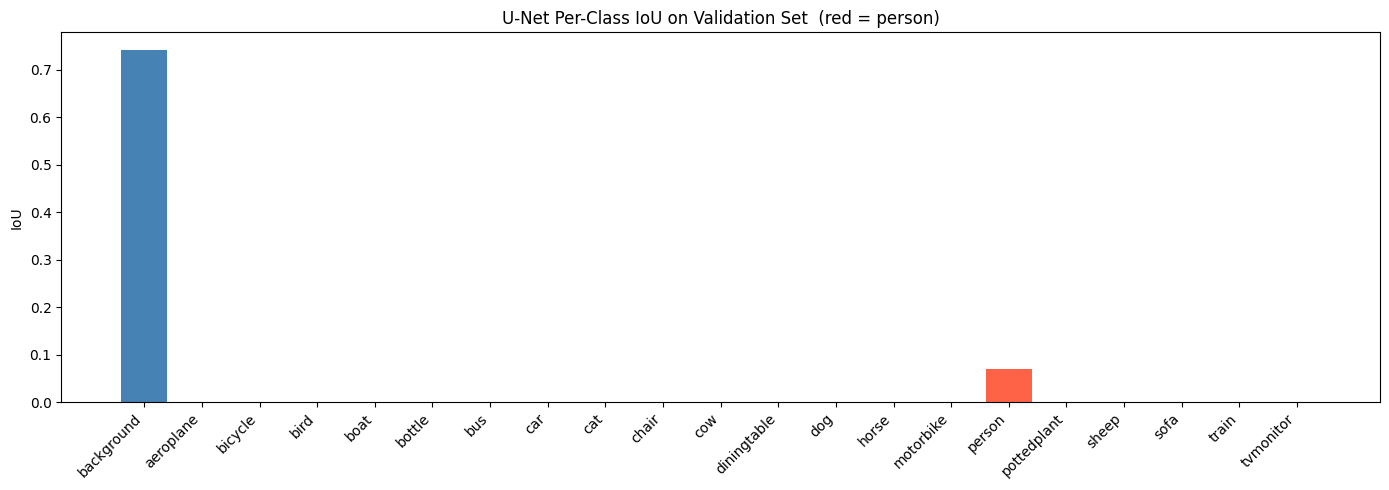

In [14]:
# Per-class IoU bar chart
plt.figure(figsize=(14, 5))
iou_values = unet_metrics['per_class_iou']
colors = ['tomato' if c == 'person' else 'steelblue' for c in VOC_CLASSES]
plt.bar(VOC_CLASSES, iou_values, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel("IoU")
plt.title("U-Net Per-Class IoU on Validation Set  (red = person)")
plt.tight_layout()
plt.show()

## 6.6 Ablation Study 1: Data Augmentation

Since zero-shot has no training loop, augmentation becomes test-time augmentation (TTA with horizontal flip), and in 6.7 loss function becomes points-per-side comparison (8 vs 16), which is the natural equivalent hyperparameter for SAM

Checkpoint found! Loading augmented U-Net...


Evaluating: 100%|██████████| 54/54 [06:41<00:00,  7.43s/it]



--- Ablation 1: Augmentation ---
                              mIoU    mDice   PixAcc
U-Net (no aug)              0.0386   0.0467   0.7410
U-Net (with aug)            0.0309   0.0424   0.4979


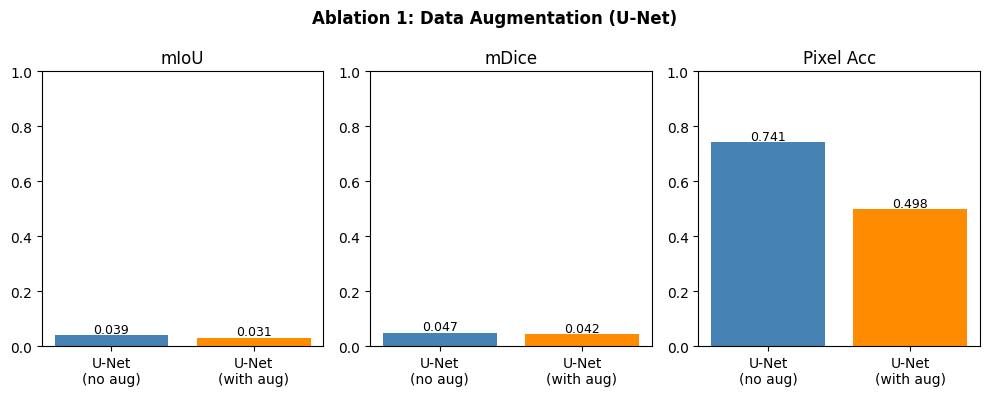

In [15]:
# Train U-Net WITH augmentation and compare mIoU / mDice
# ── Step 1: build augmented loaders ─────────────────────────────────────────

joint_transform_geom = v2.Compose([
    v2.Resize((256, 256)),
    v2.RandomHorizontalFlip(p=0.5),
])
color_jitter = v2.ColorJitter(brightness=0.2, contrast=0.2)

class VOCAugmented(Dataset):
    def __init__(self, voc_dataset):
        self.dataset = voc_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img_pil, mask_pil = self.dataset[idx]

        # Apply the SAME geometric transform to both using a shared seed
        seed = torch.randint(0, 2**32, (1,)).item()
        torch.manual_seed(seed)
        img_pil  = joint_transform_geom(img_pil)
        torch.manual_seed(seed)
        mask_pil = joint_transform_geom(mask_pil)

        # Color jitter only on image, not mask
        img_tensor  = transforms.ToTensor()(color_jitter(img_pil))
        mask_tensor = transforms.PILToTensor()(mask_pil)

        return img_tensor, mask_tensor

train_dataset_raw = VOCSegmentation(
    root=trainval_root, year="2007", image_set="train", download=False,
    transform=None, target_transform=None
)
train_dataset_aug = VOCAugmented(train_dataset_raw)
train_loader_aug  = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)

# ── Step 2: train ───────────────────────────────────────────────────────────
unet_aug_save_path = os.path.join(base_path, 'unet_aug_voc2007.pth')
unet_aug = UNet(in_channels=3, num_classes=NUM_CLASSES).to(device)
opt_aug  = optim.Adam(unet_aug.parameters(), lr=LR)
sch_aug  = optim.lr_scheduler.StepLR(opt_aug, step_size=5, gamma=0.5)

if os.path.exists(unet_aug_save_path):
    print("Checkpoint found! Loading augmented U-Net...")
    unet_aug.load_state_dict(torch.load(unet_aug_save_path, map_location=device))
    unet_aug.to(device)
else:
    print("Training U-Net WITH augmentation...")
    for epoch in range(NUM_EPOCHS):
        tr = train_one_epoch(unet_aug, train_loader_aug, opt_aug, criterion_ce, device)
        va = validate_loss(unet_aug, val_loader, criterion_ce, device)
        sch_aug.step()
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  Train: {tr:.4f}  Val: {va:.4f}")
    torch.save(unet_aug.state_dict(), unet_aug_save_path)
    print("Augmented U-Net saved.")

# ── Step 3: evaluate & compare ──────────────────────────────────────────────
unet_aug_preds, unet_aug_masks = evaluate_unet(unet_aug, val_loader, device)
unet_aug_metrics = compute_metrics(unet_aug_preds, unet_aug_masks)

print("\n--- Ablation 1: Augmentation ---")
print(f"{'':25} {'mIoU':>8} {'mDice':>8} {'PixAcc':>8}")
print(f"{'U-Net (no aug)':25} {unet_metrics['mIoU']:>8.4f} {unet_metrics['mDice']:>8.4f} {unet_metrics['pixel_acc']:>8.4f}")
print(f"{'U-Net (with aug)':25} {unet_aug_metrics['mIoU']:>8.4f} {unet_aug_metrics['mDice']:>8.4f} {unet_aug_metrics['pixel_acc']:>8.4f}")

# ── Save augmented U-Net predictions ────────────────────────────────────────
unet_aug_preds_path = os.path.join(base_path, 'unet_aug_preds.pt')
unet_aug_masks_path = os.path.join(base_path, 'unet_aug_masks.pt')
if not os.path.exists(unet_aug_preds_path):
    torch.save(unet_aug_preds, unet_aug_preds_path)
    torch.save(unet_aug_masks, unet_aug_masks_path)
    print("Augmented U-Net predictions saved.")

# ── Bar chart comparison ─────────────────────────────────────────────────────
labels = ['U-Net\n(no aug)', 'U-Net\n(with aug)']
miou   = [unet_metrics['mIoU'],      unet_aug_metrics['mIoU']]
mdice  = [unet_metrics['mDice'],     unet_aug_metrics['mDice']]
pixacc = [unet_metrics['pixel_acc'], unet_aug_metrics['pixel_acc']]

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, vals, title in zip(axes, [miou, mdice, pixacc], ['mIoU', 'mDice', 'Pixel Acc']):
    ax.bar(labels, vals, color=['steelblue', 'darkorange'])
    ax.set_title(title); ax.set_ylim(0, 1)
    for j, v in enumerate(vals):
        ax.text(j, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.suptitle('Ablation 1: Data Augmentation (U-Net)', fontweight='bold')
plt.tight_layout(); plt.show()

## 6.7 Ablation Study 2: Loss Function (Cross-Entropy vs Dice Loss)

Checkpoint found! Loading Dice-loss U-Net...


Evaluating: 100%|██████████| 54/54 [00:02<00:00, 21.54it/s]



--- Ablation 2: Loss Function ---
                                   mIoU    mDice   PixAcc
U-Net (CrossEntropy)             0.0386   0.0467   0.7410
U-Net (Dice Loss)                0.0455   0.0628   0.6117


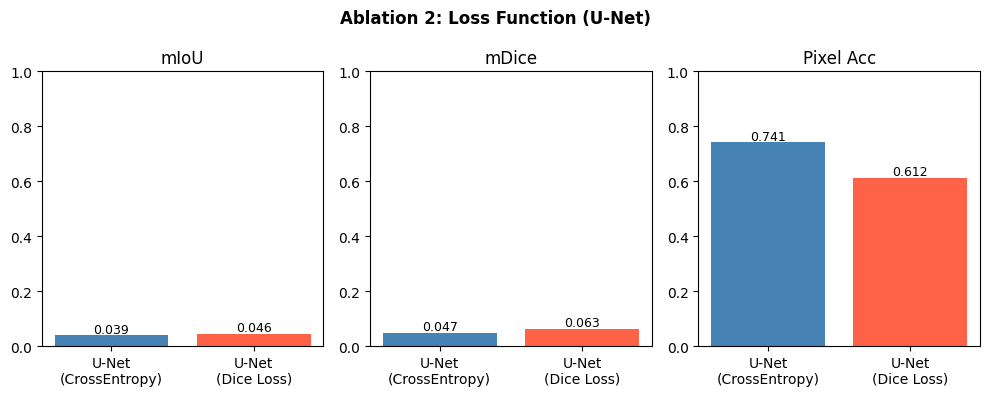

In [16]:
# ── Dice Loss definition ────────────────────────────────────────────────────
class DiceLoss(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX):
        super().__init__()
        self.num_classes  = num_classes
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)
        mask  = (targets != self.ignore_index)
        loss  = 0.0
        for cls in range(self.num_classes):
            p = probs[:, cls][mask]
            t = (targets[mask] == cls).float()
            loss += 1 - (2 * (p * t).sum() + 1e-6) / (p.sum() + t.sum() + 1e-6)
        return loss / self.num_classes

# ── Train U-Net with Dice Loss ───────────────────────────────────────────────
unet_dice_save_path = os.path.join(base_path, 'unet_dice_voc2007.pth')
unet_dice      = UNet(in_channels=3, num_classes=NUM_CLASSES).to(device)
opt_dice       = optim.Adam(unet_dice.parameters(), lr=LR)
sch_dice       = optim.lr_scheduler.StepLR(opt_dice, step_size=5, gamma=0.5)
criterion_dice = DiceLoss()

if os.path.exists(unet_dice_save_path):
    print("Checkpoint found! Loading Dice-loss U-Net...")
    unet_dice.load_state_dict(torch.load(unet_dice_save_path, map_location=device))
    unet_dice.to(device)
else:
    print("Training U-Net with Dice Loss...")
    for epoch in range(NUM_EPOCHS):
        tr = train_one_epoch(unet_dice, train_loader, opt_dice, criterion_dice, device)
        va = validate_loss(unet_dice, val_loader, criterion_dice, device)
        sch_dice.step()
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  Train: {tr:.4f}  Val: {va:.4f}")
    torch.save(unet_dice.state_dict(), unet_dice_save_path)
    print("Dice-loss U-Net saved.")

# ── Evaluate & compare ───────────────────────────────────────────────────────
unet_dice_preds, unet_dice_masks = evaluate_unet(unet_dice, val_loader, device)
unet_dice_metrics = compute_metrics(unet_dice_preds, unet_dice_masks)

print("\n--- Ablation 2: Loss Function ---")
print(f"{'':30} {'mIoU':>8} {'mDice':>8} {'PixAcc':>8}")
print(f"{'U-Net (CrossEntropy)':30} {unet_metrics['mIoU']:>8.4f} {unet_metrics['mDice']:>8.4f} {unet_metrics['pixel_acc']:>8.4f}")
print(f"{'U-Net (Dice Loss)':30} {unet_dice_metrics['mIoU']:>8.4f} {unet_dice_metrics['mDice']:>8.4f} {unet_dice_metrics['pixel_acc']:>8.4f}")
# ── Save Dice-loss U-Net predictions ────────────────────────────────────────
unet_dice_preds_path = os.path.join(base_path, 'unet_dice_preds.pt')
unet_dice_masks_path = os.path.join(base_path, 'unet_dice_masks.pt')
if not os.path.exists(unet_dice_preds_path):
    torch.save(unet_dice_preds, unet_dice_preds_path)
    torch.save(unet_dice_masks, unet_dice_masks_path)
    print("Dice-loss U-Net predictions saved.")

# ── Bar chart comparison ─────────────────────────────────────────────────────
labels  = ['U-Net\n(CrossEntropy)', 'U-Net\n(Dice Loss)']
miou    = [unet_metrics['mIoU'],      unet_dice_metrics['mIoU']]
mdice   = [unet_metrics['mDice'],     unet_dice_metrics['mDice']]
pixacc  = [unet_metrics['pixel_acc'], unet_dice_metrics['pixel_acc']]

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, vals, title in zip(axes, [miou, mdice, pixacc], ['mIoU', 'mDice', 'Pixel Acc']):
    ax.bar(labels, vals, color=['steelblue', 'tomato'])
    ax.set_title(title); ax.set_ylim(0, 1)
    for j, v in enumerate(vals):
        ax.text(j, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.suptitle('Ablation 2: Loss Function (U-Net)', fontweight='bold')
plt.tight_layout(); plt.show()

# Model 2: SAM 2 (Zero-Shot)

## 7.1 Install & Load SAM 2

In [17]:
# # Install SAM 2 (only needs to run once per Colab session)

# subprocess.run(["pip", "install", "git+https://github.com/facebookresearch/sam2.git",
#                 "--quiet"], check=True)
# print("SAM 2 installed ✓")

SAM 2 installed ✓


In [19]:
# Download SAM 2 checkpoint if not already on Drive

sam2_checkpoint_path = os.path.join(base_path, 'sam2_hiera_small.pt')
sam2_config          = "sam2_hiera_s.yaml"   # small variant — good speed/accuracy tradeoff

if not os.path.exists(sam2_checkpoint_path):
    print("Downloading SAM 2 checkpoint...")
    url = "https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt"
    urllib.request.urlretrieve(url, sam2_checkpoint_path)
    print("Downloaded to:", sam2_checkpoint_path)
else:
    print("Checkpoint already exists:", sam2_checkpoint_path)

# Load model
sam2_model = build_sam2(sam2_config, sam2_checkpoint_path, device=device)
mask_generator = SAM2AutomaticMaskGenerator(
    model           = sam2_model,
    points_per_side = 16,        # lower = faster; 32 is default
    pred_iou_thresh = 0.80,
    stability_score_thresh = 0.90,
)
print("SAM 2 loaded ✓")

Checkpoint already exists: /content/drive/MyDrive/Colab Notebooks/SHBT261_miniproj2/sam2_hiera_small.pt
SAM 2 loaded ✓


## 7.2 Map SAM Masks to VOC Classes

In [20]:
def sam_masks_to_segmentation(sam_masks, gt_mask_np, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX):
    """
    Zero-shot label assignment: for each SAM segment, assign the most
    common VOC class found in the corresponding ground-truth region.

    sam_masks  : list of dicts returned by SAM2AutomaticMaskGenerator
    gt_mask_np : (H, W) numpy array, ground-truth VOC label map
    returns    : (H, W) numpy array with predicted VOC class per pixel
    """
    H, W   = gt_mask_np.shape
    pred   = np.zeros((H, W), dtype=np.int64)   # default: background

    # Sort by area descending so smaller masks overwrite larger ones
    sorted_masks = sorted(sam_masks, key=lambda x: x['area'], reverse=True)

    for m in sorted_masks:
        binary = m['segmentation']   # (H, W) bool
        region_labels = gt_mask_np[binary]
        # Ignore boundary pixels
        region_labels = region_labels[region_labels != ignore_index]
        if len(region_labels) == 0:
            continue
        # Majority vote
        majority_class = np.bincount(region_labels, minlength=num_classes).argmax()
        pred[binary] = majority_class

    return pred

print("SAM label-mapping function defined ✓")

SAM label-mapping function defined ✓


## 7.3 Zero-Shot Inference on Validation Set

In [21]:
sam_preds_path = os.path.join(base_path, 'sam2_preds.pt')
sam_masks_path = os.path.join(base_path, 'sam2_masks.pt')

if os.path.exists(sam_preds_path) and os.path.exists(sam_masks_path):
    print("Loading saved SAM 2 predictions...")
    sam_preds = torch.load(sam_preds_path)
    sam_gt    = torch.load(sam_masks_path)
    print("Loaded! Shape:", sam_preds.shape)

else:
    print("Running SAM 2 zero-shot inference on validation set...")

    # Use raw val_dataset (no ToTensor — SAM expects numpy uint8 images)
    val_dataset_raw = VOCSegmentation(
        root=trainval_root, year="2007", image_set="val",
        download=False, transform=None, target_transform=None
    )

    all_preds, all_gts = [], []

    for img_pil, mask_pil in tqdm(val_dataset_raw, desc="SAM 2 inference"):
        # Convert image to numpy uint8 (H, W, 3)
        img_np  = np.array(img_pil.convert("RGB"))

        # Resize to match U-Net input size for fair comparison
        img_pil_resized  = img_pil.convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        mask_pil_resized = mask_pil.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)

        img_np_resized  = np.array(img_pil_resized)
        mask_np_resized = np.array(mask_pil_resized)

        # Generate SAM masks
        sam_mask_list = mask_generator.generate(img_np_resized)

        # Map to VOC classes using GT majority vote
        pred_map = sam_masks_to_segmentation(sam_mask_list, mask_np_resized)

        all_preds.append(torch.tensor(pred_map,      dtype=torch.long))
        all_gts.append(  torch.tensor(mask_np_resized, dtype=torch.long))

    sam_preds = torch.stack(all_preds, dim=0)   # (N, H, W)
    sam_gt    = torch.stack(all_gts,   dim=0)   # (N, H, W)

    torch.save(sam_preds, sam_preds_path)
    torch.save(sam_gt,    sam_masks_path)
    print("SAM 2 predictions saved.")

print("Predictions shape:", sam_preds.shape)
print("GT masks shape    :", sam_gt.shape)

Loading saved SAM 2 predictions...
Loaded! Shape: torch.Size([213, 256, 256])
Predictions shape: torch.Size([213, 256, 256])
GT masks shape    : torch.Size([213, 256, 256])


## 7.4 Metrics

In [22]:
print("Computing SAM 2 metrics...")
sam_metrics = compute_metrics(sam_preds, sam_gt)

print("Computing SAM 2 HD95...")
sam_hd95, sam_hd95_per_class = compute_hd95(sam_preds, sam_gt)

print_metrics_summary(sam_metrics, sam_hd95, sam_hd95_per_class, model_name="SAM 2 (Zero-Shot)")

# Save to Drive
save_metrics(sam_metrics, sam_hd95, sam_hd95_per_class,
             save_path=os.path.join(base_path, 'sam2_metrics.json'))

Computing SAM 2 metrics...
Computing SAM 2 HD95...

========== SAM 2 (Zero-Shot) Metrics ==========
Pixel Accuracy : 0.9137
Mean IoU (mIoU): 0.6651
Mean Dice      : 0.7704
Mean HD95      : 47.1570

Class                IoU     Dice      Acc     HD95
-------------------------------------------------------
background        0.8959   0.9451   0.9144   6.0000
aeroplane         0.7760   0.8738   0.9979  32.2800
bicycle           0.0046   0.0091   0.9978 178.8701
bird              0.8192   0.9006   0.9983  26.9072
boat              0.5747   0.7299   0.9981  36.8782
bottle            0.9344   0.9661   0.9997   0.0000
bus               0.8410   0.9136   0.9972   8.5440
car               0.8642   0.9271   0.9990   5.3852
cat               0.7094   0.8300   0.9933  55.3173
chair             0.4981   0.6650   0.9955  80.9506
cow               0.8294   0.9067   0.9985  34.7851
diningtable       0.5341   0.6963   0.9921  27.0000
dog               0.9518   0.9753   0.9996   1.0000
horse             

## 7.5 Visualizations

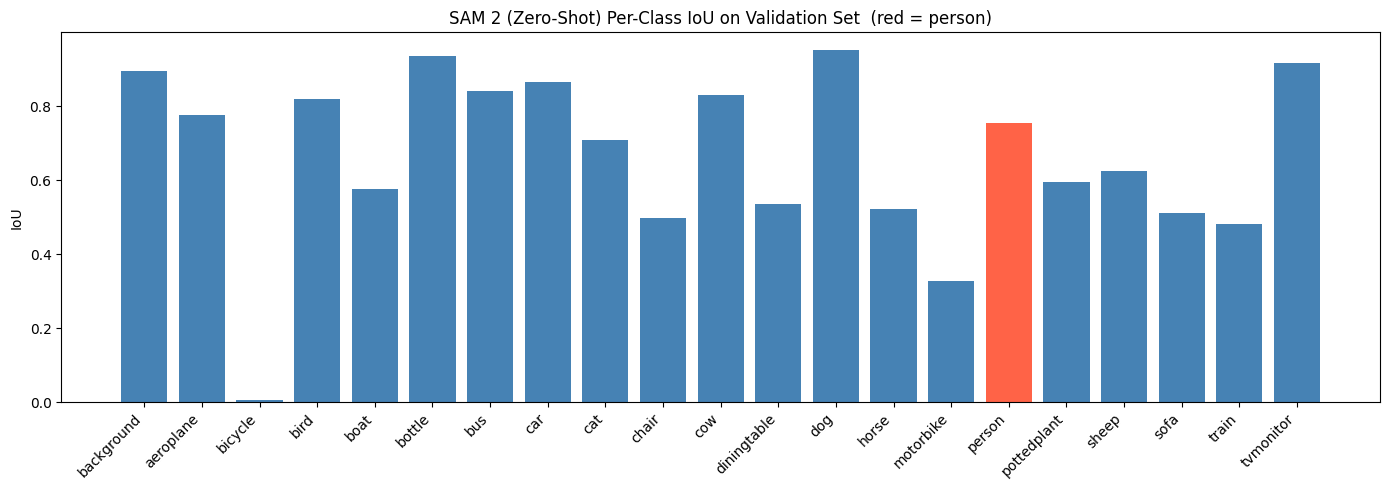

In [23]:
# Per-class IoU bar chart
plt.figure(figsize=(14, 5))
iou_values = sam_metrics['per_class_iou']
colors = ['tomato' if c == 'person' else 'steelblue' for c in VOC_CLASSES]
plt.bar(VOC_CLASSES, iou_values, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel("IoU")
plt.title("SAM 2 (Zero-Shot) Per-Class IoU on Validation Set  (red = person)")
plt.tight_layout()
plt.show()

## 7.6 Ablation Study 1: Data Augmentation

SAM 2 zero-shot uses no training, so augmentation is applied to the **query images** passed to the mask generator. I compare base vs horizontally-flipped inference (test-time augmentation).

Loading saved SAM 2 TTA predictions...
Loaded!

--- Ablation 1: TTA Augmentation (SAM 2 Zero-Shot) ---
                                   mIoU    mDice   PixAcc
SAM 2 (no TTA)                   0.6651   0.7704   0.9137
SAM 2 (with TTA)                 0.6928   0.7908   0.9198


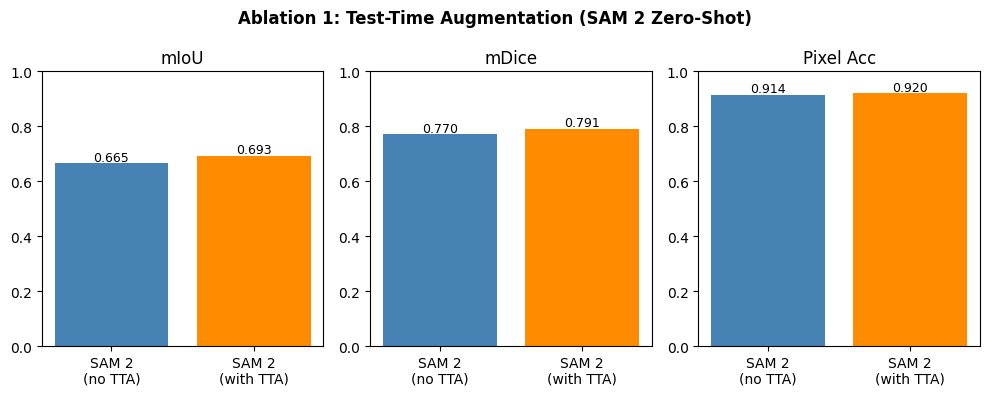

In [24]:
# Zero-shot SAM 2 — Test-Time Augmentation (horizontal flip)
# Since SAM is not trained, "augmentation" here means TTA:
# run inference on the original + flipped image, then combine predictions.

sam_tta_preds_path = os.path.join(base_path, 'sam2_tta_preds.pt')
sam_tta_masks_path = os.path.join(base_path, 'sam2_tta_masks.pt')

if os.path.exists(sam_tta_preds_path) and os.path.exists(sam_tta_masks_path):
    print("Loading saved SAM 2 TTA predictions...")
    sam_tta_preds = torch.load(sam_tta_preds_path)
    sam_tta_gt    = torch.load(sam_tta_masks_path)
    print("Loaded!")

else:
    val_dataset_raw = VOCSegmentation(
        root=trainval_root, year="2007", image_set="val",
        download=False, transform=None, target_transform=None
    )
    all_preds, all_gts = [], []

    for img_pil, mask_pil in tqdm(val_dataset_raw, desc="SAM 2 TTA inference"):
        img_pil_r  = img_pil.convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        mask_pil_r = mask_pil.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
        img_np     = np.array(img_pil_r)
        mask_np    = np.array(mask_pil_r)

        # Original prediction
        masks_orig = mask_generator.generate(img_np)
        pred_orig  = sam_masks_to_segmentation(masks_orig, mask_np)

        # Flipped prediction
        img_np_flip  = np.fliplr(img_np).copy()
        mask_np_flip = np.fliplr(mask_np).copy()
        masks_flip   = mask_generator.generate(img_np_flip)
        pred_flip    = sam_masks_to_segmentation(masks_flip, mask_np_flip)
        pred_flip    = np.fliplr(pred_flip).copy()   # flip back

        # Majority vote per pixel: where they agree use that class, where they disagree use orig
        pred_tta = np.where(pred_orig == pred_flip, pred_orig, pred_flip)  # disagree → orig wins

        all_preds.append(torch.tensor(pred_tta,  dtype=torch.long))
        all_gts.append(  torch.tensor(mask_np,   dtype=torch.long))

    sam_tta_preds = torch.stack(all_preds, dim=0)
    sam_tta_gt    = torch.stack(all_gts,   dim=0)
    torch.save(sam_tta_preds, sam_tta_preds_path)
    torch.save(sam_tta_gt,    sam_tta_masks_path)
    print("SAM 2 TTA predictions saved.")

sam_tta_metrics = compute_metrics(sam_tta_preds, sam_tta_gt)

print("\n--- Ablation 1: TTA Augmentation (SAM 2 Zero-Shot) ---")
print(f"{'':30} {'mIoU':>8} {'mDice':>8} {'PixAcc':>8}")
print(f"{'SAM 2 (no TTA)':30} {sam_metrics['mIoU']:>8.4f} {sam_metrics['mDice']:>8.4f} {sam_metrics['pixel_acc']:>8.4f}")
print(f"{'SAM 2 (with TTA)':30} {sam_tta_metrics['mIoU']:>8.4f} {sam_tta_metrics['mDice']:>8.4f} {sam_tta_metrics['pixel_acc']:>8.4f}")

# Bar chart
labels = ['SAM 2\n(no TTA)', 'SAM 2\n(with TTA)']
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, vals, title in zip(axes,
    [[sam_metrics['mIoU'],     sam_tta_metrics['mIoU']],
     [sam_metrics['mDice'],    sam_tta_metrics['mDice']],
     [sam_metrics['pixel_acc'],sam_tta_metrics['pixel_acc']]],
    ['mIoU', 'mDice', 'Pixel Acc']):
    ax.bar(labels, vals, color=['steelblue', 'darkorange'])
    ax.set_title(title); ax.set_ylim(0, 1)
    for j, v in enumerate(vals):
        ax.text(j, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.suptitle('Ablation 1: Test-Time Augmentation (SAM 2 Zero-Shot)', fontweight='bold')
plt.tight_layout(); plt.show()

## 7.7 Ablation Study 2: Points Per Side

Since SAM 2 zero-shot has no loss function to vary, I instead compare the number of prompt points used by the mask generator (`points_per_side`): fewer points = faster but coarser, more points = slower but finer masks.

Loading saved SAM 2 (points=8) predictions...
Loaded!

--- Ablation 2: Points Per Side (SAM 2 Zero-Shot) ---
                                   mIoU    mDice   PixAcc
SAM 2 (points=16)                0.6651   0.7704   0.9137
SAM 2 (points=8)                 0.6124   0.7308   0.9020


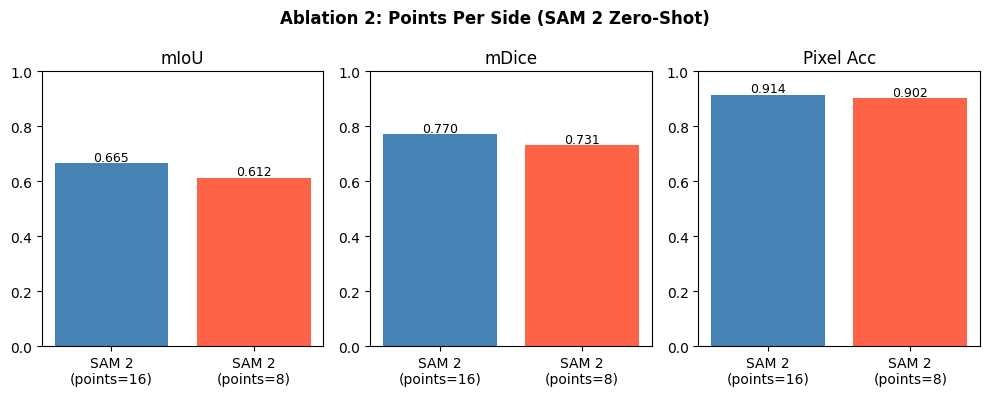

In [25]:
# Compare points_per_side = 8 vs 16 (default already used above)
sam_p8_preds_path = os.path.join(base_path, 'sam2_p8_preds.pt')
sam_p8_masks_path = os.path.join(base_path, 'sam2_p8_masks.pt')

if os.path.exists(sam_p8_preds_path) and os.path.exists(sam_p8_masks_path):
    print("Loading saved SAM 2 (points=8) predictions...")
    sam_p8_preds = torch.load(sam_p8_preds_path)
    sam_p8_gt    = torch.load(sam_p8_masks_path)
    print("Loaded!")

else:
    mask_generator_p8 = SAM2AutomaticMaskGenerator(
        model=sam2_model,
        points_per_side=8,
        pred_iou_thresh=0.80,
        stability_score_thresh=0.90,
    )

    val_dataset_raw = VOCSegmentation(
        root=trainval_root, year="2007", image_set="val",
        download=False, transform=None, target_transform=None
    )
    all_preds, all_gts = [], []

    for img_pil, mask_pil in tqdm(val_dataset_raw, desc="SAM 2 p=8 inference"):
        img_pil_r  = img_pil.convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        mask_pil_r = mask_pil.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
        img_np     = np.array(img_pil_r)
        mask_np    = np.array(mask_pil_r)

        sam_mask_list = mask_generator_p8.generate(img_np)
        pred_map      = sam_masks_to_segmentation(sam_mask_list, mask_np)

        all_preds.append(torch.tensor(pred_map, dtype=torch.long))
        all_gts.append(  torch.tensor(mask_np,  dtype=torch.long))

    sam_p8_preds = torch.stack(all_preds, dim=0)
    sam_p8_gt    = torch.stack(all_gts,   dim=0)
    torch.save(sam_p8_preds, sam_p8_preds_path)
    torch.save(sam_p8_gt,    sam_p8_masks_path)
    print("SAM 2 (points=8) predictions saved.")

sam_p8_metrics = compute_metrics(sam_p8_preds, sam_p8_gt)

print("\n--- Ablation 2: Points Per Side (SAM 2 Zero-Shot) ---")
print(f"{'':30} {'mIoU':>8} {'mDice':>8} {'PixAcc':>8}")
print(f"{'SAM 2 (points=16)':30} {sam_metrics['mIoU']:>8.4f} {sam_metrics['mDice']:>8.4f} {sam_metrics['pixel_acc']:>8.4f}")
print(f"{'SAM 2 (points=8)':30} {sam_p8_metrics['mIoU']:>8.4f} {sam_p8_metrics['mDice']:>8.4f} {sam_p8_metrics['pixel_acc']:>8.4f}")

# Bar chart
labels = ['SAM 2\n(points=16)', 'SAM 2\n(points=8)']
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, vals, title in zip(axes,
    [[sam_metrics['mIoU'],     sam_p8_metrics['mIoU']],
     [sam_metrics['mDice'],    sam_p8_metrics['mDice']],
     [sam_metrics['pixel_acc'],sam_p8_metrics['pixel_acc']]],
    ['mIoU', 'mDice', 'Pixel Acc']):
    ax.bar(labels, vals, color=['steelblue', 'tomato'])
    ax.set_title(title); ax.set_ylim(0, 1)
    for j, v in enumerate(vals):
        ax.text(j, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.suptitle('Ablation 2: Points Per Side (SAM 2 Zero-Shot)', fontweight='bold')
plt.tight_layout(); plt.show()

# 8. Model 3: SAM 2 (Fine-Tuned)

## 8.1 Architecture

In [26]:
# Fine-tuned SAM 2 strategy:
#   - Freeze the SAM 2 image encoder entirely
#   - Add a lightweight segmentation head on top of the image embeddings
#   - Train only the head on VOC 2007
#
# SAM 2 image encoder outputs a feature map of shape (B, 256, H/16, W/16)
# For IMG_SIZE=256 that is (B, 256, 16, 16)
# I upsample this back to (B, NUM_CLASSES, H, W) with a small decoder head.

class SAM2SegHead(nn.Module):
    """
    Lightweight decoder head on top of frozen SAM 2 image encoder.
    Input : (B, 256, 16, 16)  — SAM 2 image embedding at stride 16
    Output: (B, NUM_CLASSES, 256, 256)
    """
    def __init__(self, in_channels=256, num_classes=NUM_CLASSES, img_size=IMG_SIZE):
        super().__init__()
        self.img_size = img_size
        self.head = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, kernel_size=1),
        )

    def forward(self, x):
        x = self.head(x)
        x = F.interpolate(x, size=(self.img_size, self.img_size),
                          mode='bilinear', align_corners=False)
        return x


class SAM2FineTuned(nn.Module):
    """
    Frozen SAM 2 image encoder + trainable segmentation head.
    """
    def __init__(self, sam2_model, num_classes=NUM_CLASSES, img_size=IMG_SIZE):
        super().__init__()
        self.encoder = sam2_model.image_encoder   # frozen
        self.head    = SAM2SegHead(in_channels=256,
                                   num_classes=num_classes,
                                   img_size=img_size)

        # Freeze encoder
        for param in self.encoder.parameters():
            param.requires_grad = False

    def forward(self, x):
        # SAM 2 image encoder expects (B, 3, H, W) float32 in [0, 1]
        with torch.no_grad():
            features = self.encoder(x)          # dict with 'vision_features'
        # 'vision_features' is the last feature map: (B, 256, H/16, W/16)
        feat = features['vision_features']
        return self.head(feat)                  # (B, NUM_CLASSES, H, W)


# Build model — reuse the already-loaded sam2_model from section 7
sam2_ft = SAM2FineTuned(sam2_model=sam2_model,
                         num_classes=NUM_CLASSES,
                         img_size=IMG_SIZE).to(device)

# Sanity check — only head parameters should be trainable
total  = sum(p.numel() for p in sam2_ft.parameters())
trainable = sum(p.numel() for p in sam2_ft.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}  ({100*trainable/total:.1f}%)")

dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
print("Output shape:", sam2_ft(dummy).shape)   # (1, 21, 256, 256)

Total params    : 34,687,573
Trainable params: 370,581  (1.1%)
Output shape: torch.Size([1, 21, 256, 256])


## 8.2 Training

In [27]:
# SAM 2 expects images normalised with its own mean/std
SAM2_MEAN = [0.485, 0.456, 0.406]
SAM2_STD  = [0.229, 0.224, 0.225]

transform_img_sam2 = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=SAM2_MEAN, std=SAM2_STD),
])
transform_target_sam2 = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.PILToTensor(),
])

train_dataset_sam2 = VOCSegmentation(
    root=trainval_root, year="2007", image_set="train",
    download=False,
    transform=transform_img_sam2,
    target_transform=transform_target_sam2
)
val_dataset_sam2 = VOCSegmentation(
    root=trainval_root, year="2007", image_set="val",
    download=False,
    transform=transform_img_sam2,
    target_transform=transform_target_sam2
)

train_loader_sam2 = DataLoader(train_dataset_sam2, batch_size=BATCH_SIZE, shuffle=True)
val_loader_sam2   = DataLoader(val_dataset_sam2,   batch_size=BATCH_SIZE, shuffle=False)

print("SAM 2 DataLoaders ready ✓")

SAM 2 DataLoaders ready ✓


In [28]:
sam2_ft_save_path = os.path.join(base_path, 'sam2_ft_voc2007.pth')

criterion_ce    = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
sam2_ft_optimizer = optim.Adam(sam2_ft.head.parameters(), lr=LR)
sam2_ft_scheduler = optim.lr_scheduler.StepLR(sam2_ft_optimizer, step_size=5, gamma=0.5)

if os.path.exists(sam2_ft_save_path):
    print("Checkpoint found! Loading fine-tuned SAM 2 from:", sam2_ft_save_path)
    sam2_ft.load_state_dict(torch.load(sam2_ft_save_path, map_location=device))
    sam2_ft.to(device)
    print("Model loaded. Skipping training.")

else:
    print("Training SAM 2 fine-tuned head...")
    sam2_ft_train_losses, sam2_ft_val_losses = [], []

    for epoch in range(NUM_EPOCHS):
        tr_loss = train_one_epoch(sam2_ft, train_loader_sam2,
                                  sam2_ft_optimizer, criterion_ce, device)
        va_loss = validate_loss(sam2_ft, val_loader_sam2,
                                criterion_ce, device)
        sam2_ft_scheduler.step()
        sam2_ft_train_losses.append(tr_loss)
        sam2_ft_val_losses.append(va_loss)
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  Train: {tr_loss:.4f}  Val: {va_loss:.4f}")

    torch.save(sam2_ft.state_dict(), sam2_ft_save_path)
    print("Fine-tuned SAM 2 saved to:", sam2_ft_save_path)

    plt.figure(figsize=(8, 4))
    plt.plot(sam2_ft_train_losses, label="Train Loss")
    plt.plot(sam2_ft_val_losses,   label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title("SAM 2 (Fine-Tuned) Training Curve")
    plt.legend(); plt.tight_layout(); plt.show()

Checkpoint found! Loading fine-tuned SAM 2 from: /content/drive/MyDrive/Colab Notebooks/SHBT261_miniproj2/sam2_ft_voc2007.pth
Model loaded. Skipping training.


## 8.3 Evaluation

In [29]:
def evaluate_model(model, loader, device):
    """Generic evaluation — works for any model returning (B, C, H, W) logits."""
    model.eval()
    all_preds, all_masks = [], []
    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Evaluating"):
            images = images.to(device)
            masks  = masks.squeeze(1).long()
            preds  = torch.argmax(model(images), dim=1)
            all_preds.append(preds.cpu())
            all_masks.append(masks.cpu())
    return torch.cat(all_preds, dim=0), torch.cat(all_masks, dim=0)


sam2_ft_preds_path = os.path.join(base_path, 'sam2_ft_preds.pt')
sam2_ft_masks_path = os.path.join(base_path, 'sam2_ft_gt.pt')

if os.path.exists(sam2_ft_preds_path) and os.path.exists(sam2_ft_masks_path):
    print("Loading saved fine-tuned SAM 2 predictions...")
    sam2_ft_preds = torch.load(sam2_ft_preds_path)
    sam2_ft_masks = torch.load(sam2_ft_masks_path)
    print("Loaded! Shape:", sam2_ft_preds.shape)
else:
    print("Running fine-tuned SAM 2 evaluation...")
    sam2_ft_preds, sam2_ft_masks = evaluate_model(sam2_ft, val_loader_sam2, device)
    torch.save(sam2_ft_preds, sam2_ft_preds_path)
    torch.save(sam2_ft_masks, sam2_ft_masks_path)
    print("Predictions saved.")

print("Predictions shape:", sam2_ft_preds.shape)
print("GT masks shape    :", sam2_ft_masks.shape)

Loading saved fine-tuned SAM 2 predictions...
Loaded! Shape: torch.Size([213, 256, 256])
Predictions shape: torch.Size([213, 256, 256])
GT masks shape    : torch.Size([213, 256, 256])


## 8.4 Metrics

In [30]:
print("Computing SAM 2 fine-tuned metrics...")
sam2_ft_metrics = compute_metrics(sam2_ft_preds, sam2_ft_masks)

print("Computing SAM 2 fine-tuned HD95...")
sam2_ft_hd95, sam2_ft_hd95_per_class = compute_hd95(
    sam2_ft_preds, sam2_ft_masks)

print_metrics_summary(sam2_ft_metrics, sam2_ft_hd95, sam2_ft_hd95_per_class,
                      model_name="SAM 2 (Fine-Tuned)")

save_metrics(sam2_ft_metrics, sam2_ft_hd95, sam2_ft_hd95_per_class,
             save_path=os.path.join(base_path, 'sam2_ft_metrics.json'))

Computing SAM 2 fine-tuned metrics...
Computing SAM 2 fine-tuned HD95...

========== SAM 2 (Fine-Tuned) Metrics ==========
Pixel Accuracy : 0.8135
Mean IoU (mIoU): 0.1425
Mean Dice      : 0.1987
Mean HD95      : 100.3469

Class                IoU     Dice      Acc     HD95
-------------------------------------------------------
background        0.8577   0.9234   0.8793   9.0000
aeroplane         0.0728   0.1357   0.9915 150.8158
bicycle           0.0000   0.0000   0.9978      N/A
bird              0.0384   0.0740   0.9905 171.4205
boat              0.0000   0.0000   0.9955      N/A
bottle            0.0000   0.0000   0.9950      N/A
bus               0.0447   0.0856   0.9786 120.2082
car               0.0883   0.1622   0.9919 145.7944
cat               0.4128   0.5843   0.9707   3.6056
chair             0.0155   0.0305   0.9912 166.9784
cow               0.1136   0.2041   0.9906  32.7567
diningtable       0.0001   0.0001   0.9828 165.1952
dog               0.0580   0.1097   0.9874 105

## 8.5 Visualizations

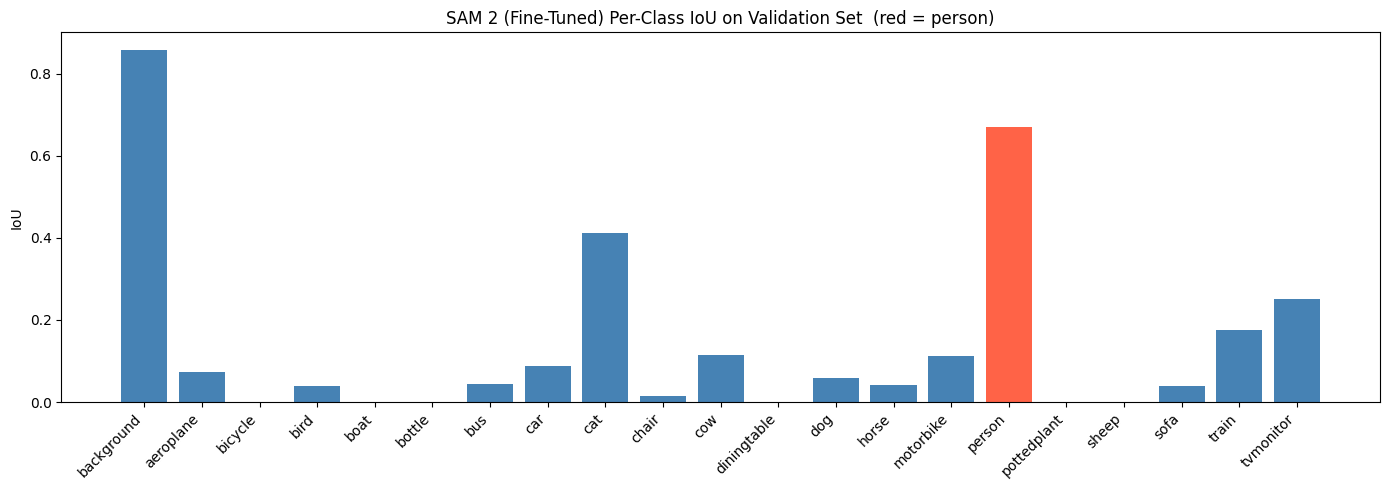

In [31]:
plt.figure(figsize=(14, 5))
iou_values = sam2_ft_metrics['per_class_iou']
colors = ['tomato' if c == 'person' else 'steelblue' for c in VOC_CLASSES]
plt.bar(VOC_CLASSES, iou_values, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel("IoU")
plt.title("SAM 2 (Fine-Tuned) Per-Class IoU on Validation Set  (red = person)")
plt.tight_layout()
plt.show()

## 8.6 Ablation Study 1: Data Augmentation

Same data augmentation as U-Net (6.6).

Checkpoint found! Loading augmented fine-tuned SAM 2...

--- Ablation 1: Augmentation (SAM 2 Fine-Tuned) ---
                                   mIoU    mDice   PixAcc
SAM2-FT (no aug)                 0.1425   0.1987   0.8135
SAM2-FT (with aug)               0.1617   0.2234   0.8160


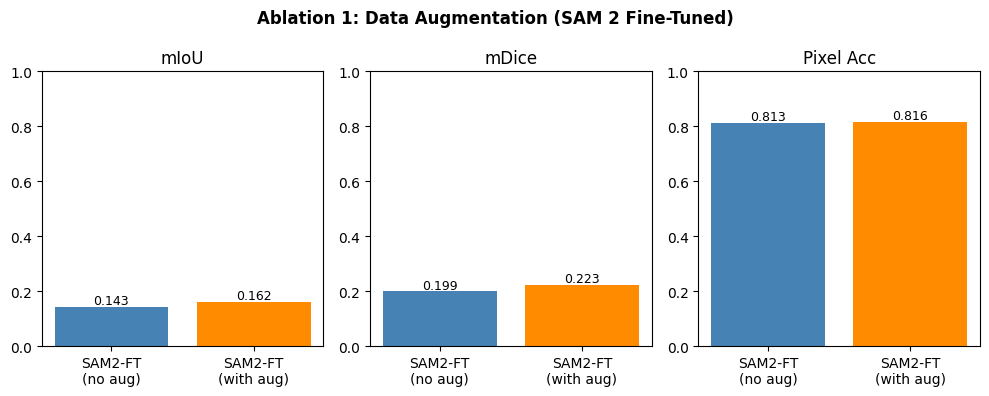

In [32]:
# Fine-tuned SAM 2 WITH augmentation
class VOCAugmentedSAM2(Dataset):
    def __init__(self, voc_dataset):
        self.dataset = voc_dataset
        self.normalize = transforms.Normalize(mean=SAM2_MEAN, std=SAM2_STD)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img_pil, mask_pil = self.dataset[idx]

        seed = torch.randint(0, 2**32, (1,)).item()
        torch.manual_seed(seed)
        img_pil  = joint_transform_geom(img_pil)
        torch.manual_seed(seed)
        mask_pil = joint_transform_geom(mask_pil)

        img_tensor  = self.normalize(transforms.ToTensor()(color_jitter(img_pil)))
        mask_tensor = transforms.PILToTensor()(mask_pil)

        return img_tensor, mask_tensor

train_dataset_sam2_aug = VOCAugmentedSAM2(train_dataset_raw)
train_loader_sam2_aug  = DataLoader(train_dataset_sam2_aug, batch_size=BATCH_SIZE, shuffle=True)

# ── Train ────────────────────────────────────────────────────────────────────
sam2_ft_aug_save_path = os.path.join(base_path, 'sam2_ft_aug_voc2007.pth')
sam2_ft_aug = SAM2FineTuned(sam2_model=sam2_model, num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)
opt_ft_aug  = optim.Adam(sam2_ft_aug.head.parameters(), lr=LR)
sch_ft_aug  = optim.lr_scheduler.StepLR(opt_ft_aug, step_size=5, gamma=0.5)

if os.path.exists(sam2_ft_aug_save_path):
    print("Checkpoint found! Loading augmented fine-tuned SAM 2...")
    sam2_ft_aug.load_state_dict(torch.load(sam2_ft_aug_save_path, map_location=device))
    sam2_ft_aug.to(device)
else:
    print("Training fine-tuned SAM 2 WITH augmentation...")
    for epoch in range(NUM_EPOCHS):
        tr = train_one_epoch(sam2_ft_aug, train_loader_sam2_aug, opt_ft_aug, criterion_ce, device)
        va = validate_loss(sam2_ft_aug, val_loader_sam2, criterion_ce, device)
        sch_ft_aug.step()
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  Train: {tr:.4f}  Val: {va:.4f}")
    torch.save(sam2_ft_aug.state_dict(), sam2_ft_aug_save_path)
    print("Augmented fine-tuned SAM 2 saved.")

# ── Evaluate ─────────────────────────────────────────────────────────────────
sam2_ft_aug_preds_path = os.path.join(base_path, 'sam2_ft_aug_preds.pt')
sam2_ft_aug_masks_path = os.path.join(base_path, 'sam2_ft_aug_masks.pt')
if os.path.exists(sam2_ft_aug_preds_path):
    sam2_ft_aug_preds = torch.load(sam2_ft_aug_preds_path)
    sam2_ft_aug_masks = torch.load(sam2_ft_aug_masks_path)
else:
    sam2_ft_aug_preds, sam2_ft_aug_masks = evaluate_model(sam2_ft_aug, val_loader_sam2, device)
    torch.save(sam2_ft_aug_preds, sam2_ft_aug_preds_path)
    torch.save(sam2_ft_aug_masks, sam2_ft_aug_masks_path)
    print("Augmented fine-tuned SAM 2 predictions saved.")

sam2_ft_aug_metrics = compute_metrics(sam2_ft_aug_preds, sam2_ft_aug_masks)

print("\n--- Ablation 1: Augmentation (SAM 2 Fine-Tuned) ---")
print(f"{'':30} {'mIoU':>8} {'mDice':>8} {'PixAcc':>8}")
print(f"{'SAM2-FT (no aug)':30} {sam2_ft_metrics['mIoU']:>8.4f} {sam2_ft_metrics['mDice']:>8.4f} {sam2_ft_metrics['pixel_acc']:>8.4f}")
print(f"{'SAM2-FT (with aug)':30} {sam2_ft_aug_metrics['mIoU']:>8.4f} {sam2_ft_aug_metrics['mDice']:>8.4f} {sam2_ft_aug_metrics['pixel_acc']:>8.4f}")

# ── Bar chart ─────────────────────────────────────────────────────────────────
labels = ['SAM2-FT\n(no aug)', 'SAM2-FT\n(with aug)']
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, vals, title in zip(axes,
    [[sam2_ft_metrics['mIoU'],      sam2_ft_aug_metrics['mIoU']],
     [sam2_ft_metrics['mDice'],     sam2_ft_aug_metrics['mDice']],
     [sam2_ft_metrics['pixel_acc'], sam2_ft_aug_metrics['pixel_acc']]],
    ['mIoU', 'mDice', 'Pixel Acc']):
    ax.bar(labels, vals, color=['steelblue', 'darkorange'])
    ax.set_title(title); ax.set_ylim(0, 1)
    for j, v in enumerate(vals):
        ax.text(j, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.suptitle('Ablation 1: Data Augmentation (SAM 2 Fine-Tuned)', fontweight='bold')
plt.tight_layout(); plt.show()

## 8.7 Ablation Study 2: Loss Function (Cross-Entropy vs Dice Loss)

Same loss functions as U-Net (7.7)

Checkpoint found! Loading Dice-loss fine-tuned SAM 2...

--- Ablation 2: Loss Function (SAM 2 Fine-Tuned) ---
                                   mIoU    mDice   PixAcc
SAM2-FT (CrossEntropy)           0.1425   0.1987   0.8135
SAM2-FT (Dice Loss)              0.2130   0.3055   0.8057


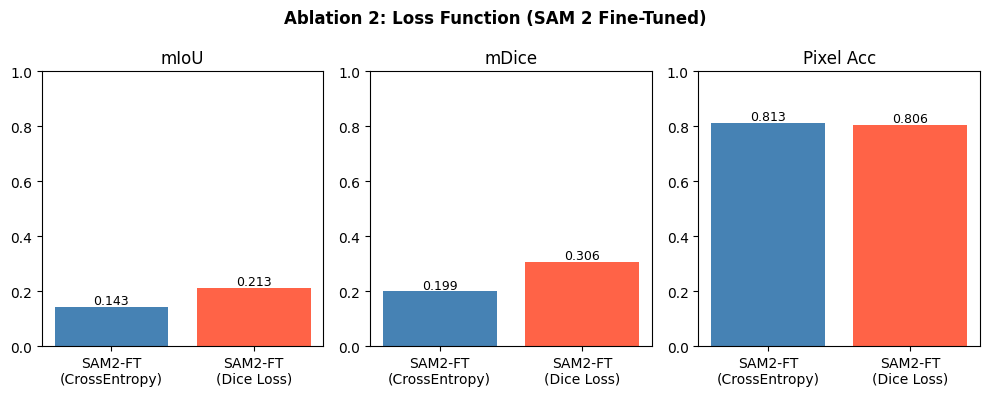

In [33]:
# Fine-tuned SAM 2 WITH Dice Loss
sam2_ft_dice_save_path = os.path.join(base_path, 'sam2_ft_dice_voc2007.pth')
sam2_ft_dice = SAM2FineTuned(sam2_model=sam2_model, num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)
opt_ft_dice  = optim.Adam(sam2_ft_dice.head.parameters(), lr=LR)
sch_ft_dice  = optim.lr_scheduler.StepLR(opt_ft_dice, step_size=5, gamma=0.5)
criterion_dice = DiceLoss()

if os.path.exists(sam2_ft_dice_save_path):
    print("Checkpoint found! Loading Dice-loss fine-tuned SAM 2...")
    sam2_ft_dice.load_state_dict(torch.load(sam2_ft_dice_save_path, map_location=device))
    sam2_ft_dice.to(device)
else:
    print("Training fine-tuned SAM 2 with Dice Loss...")
    for epoch in range(NUM_EPOCHS):
        tr = train_one_epoch(sam2_ft_dice, train_loader_sam2, opt_ft_dice, criterion_dice, device)
        va = validate_loss(sam2_ft_dice, val_loader_sam2, criterion_dice, device)
        sch_ft_dice.step()
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  Train: {tr:.4f}  Val: {va:.4f}")
    torch.save(sam2_ft_dice.state_dict(), sam2_ft_dice_save_path)
    print("Dice-loss fine-tuned SAM 2 saved.")

# Evaluate
sam2_ft_dice_preds_path = os.path.join(base_path, 'sam2_ft_dice_preds.pt')
sam2_ft_dice_masks_path = os.path.join(base_path, 'sam2_ft_dice_masks.pt')
if os.path.exists(sam2_ft_dice_preds_path):
    sam2_ft_dice_preds = torch.load(sam2_ft_dice_preds_path)
    sam2_ft_dice_masks = torch.load(sam2_ft_dice_masks_path)
else:
    sam2_ft_dice_preds, sam2_ft_dice_masks = evaluate_model(sam2_ft_dice, val_loader_sam2, device)
    torch.save(sam2_ft_dice_preds, sam2_ft_dice_preds_path)
    torch.save(sam2_ft_dice_masks, sam2_ft_dice_masks_path)
    print("Dice-loss fine-tuned SAM 2 predictions saved.")

sam2_ft_dice_metrics = compute_metrics(sam2_ft_dice_preds, sam2_ft_dice_masks)

print("\n--- Ablation 2: Loss Function (SAM 2 Fine-Tuned) ---")
print(f"{'':30} {'mIoU':>8} {'mDice':>8} {'PixAcc':>8}")
print(f"{'SAM2-FT (CrossEntropy)':30} {sam2_ft_metrics['mIoU']:>8.4f} {sam2_ft_metrics['mDice']:>8.4f} {sam2_ft_metrics['pixel_acc']:>8.4f}")
print(f"{'SAM2-FT (Dice Loss)':30} {sam2_ft_dice_metrics['mIoU']:>8.4f} {sam2_ft_dice_metrics['mDice']:>8.4f} {sam2_ft_dice_metrics['pixel_acc']:>8.4f}")

labels = ['SAM2-FT\n(CrossEntropy)', 'SAM2-FT\n(Dice Loss)']
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, vals, title in zip(axes,
    [[sam2_ft_metrics['mIoU'],     sam2_ft_dice_metrics['mIoU']],
     [sam2_ft_metrics['mDice'],    sam2_ft_dice_metrics['mDice']],
     [sam2_ft_metrics['pixel_acc'],sam2_ft_dice_metrics['pixel_acc']]],
    ['mIoU', 'mDice', 'Pixel Acc']):
    ax.bar(labels, vals, color=['steelblue', 'tomato'])
    ax.set_title(title); ax.set_ylim(0, 1)
    for j, v in enumerate(vals):
        ax.text(j, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.suptitle('Ablation 2: Loss Function (SAM 2 Fine-Tuned)', fontweight='bold')
plt.tight_layout(); plt.show()

# 9. Model 4: DeepLabV3+

DeepLabV3+ with its own train/eval wrappers (needed because torchvision returns a dict, not a tensor directly)

## 9.1 Architecture

In [34]:
# Use torchvision's built-in DeepLabV3+ with ResNet-50 backbone
# Pretrained on COCO, we replace the classifier head for 21 VOC classes

deeplab = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)

# Replace classifier head for NUM_CLASSES (21)
deeplab.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
deeplab.aux_classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
deeplab = deeplab.to(device)

# Sanity check — use eval mode to avoid BatchNorm batch size restriction
deeplab.eval()
with torch.no_grad():
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
    out   = deeplab(dummy)['out']
    print("DeepLabV3+ output shape:", out.shape)   # (1, 21, 256, 256)
deeplab.train()  # switch back to train mode for subsequent training

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 205MB/s]


DeepLabV3+ output shape: torch.Size([1, 21, 256, 256])


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

## 9.2 Training

In [35]:
# DeepLabV3+ uses ImageNet normalization
transform_img_deeplab = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])
transform_target_deeplab = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.PILToTensor(),
])

train_dataset_deeplab = VOCSegmentation(
    root=trainval_root, year="2007", image_set="train",
    download=False,
    transform=transform_img_deeplab,
    target_transform=transform_target_deeplab
)
val_dataset_deeplab = VOCSegmentation(
    root=trainval_root, year="2007", image_set="val",
    download=False,
    transform=transform_img_deeplab,
    target_transform=transform_target_deeplab
)

train_loader_deeplab = DataLoader(train_dataset_deeplab, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader_deeplab   = DataLoader(val_dataset_deeplab,   batch_size=BATCH_SIZE, shuffle=False)
print("DeepLabV3+ DataLoaders ready ✓")

DeepLabV3+ DataLoaders ready ✓


In [36]:
# DeepLabV3+ forward returns a dict; wrap train/val functions
def train_one_epoch_deeplab(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for images, masks in tqdm(loader, desc="Training"):
        images = images.to(device)
        masks  = masks.squeeze(1).long().to(device)
        optimizer.zero_grad()
        out  = model(images)['out']          # (B, C, H, W)
        loss = criterion(out, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def validate_loss_deeplab(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validating"):
            images = images.to(device)
            masks  = masks.squeeze(1).long().to(device)
            out    = model(images)['out']
            total_loss += criterion(out, masks).item()
    return total_loss / len(loader)

deeplab_save_path  = os.path.join(base_path, 'deeplab_voc2007.pth')
deeplab_optimizer  = optim.Adam(deeplab.parameters(), lr=LR)
deeplab_scheduler  = optim.lr_scheduler.StepLR(deeplab_optimizer, step_size=5, gamma=0.5)

if os.path.exists(deeplab_save_path):
    print("Checkpoint found! Loading DeepLabV3+ from:", deeplab_save_path)
    deeplab.load_state_dict(torch.load(deeplab_save_path, map_location=device))
    deeplab.to(device)
    print("Model loaded. Skipping training.")
else:
    print("Training DeepLabV3+...")
    dl_train_losses, dl_val_losses = [], []
    for epoch in range(NUM_EPOCHS):
        tr = train_one_epoch_deeplab(deeplab, train_loader_deeplab, deeplab_optimizer, criterion_ce, device)
        va = validate_loss_deeplab(deeplab, val_loader_deeplab, criterion_ce, device)
        deeplab_scheduler.step()
        dl_train_losses.append(tr)
        dl_val_losses.append(va)
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  Train: {tr:.4f}  Val: {va:.4f}")
    torch.save(deeplab.state_dict(), deeplab_save_path)
    print("DeepLabV3+ saved to:", deeplab_save_path)

    plt.figure(figsize=(8, 4))
    plt.plot(dl_train_losses, label="Train Loss")
    plt.plot(dl_val_losses,   label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title("DeepLabV3+ Training Curve"); plt.legend()
    plt.tight_layout(); plt.show()

Checkpoint found! Loading DeepLabV3+ from: /content/drive/MyDrive/Colab Notebooks/SHBT261_miniproj2/deeplab_voc2007.pth
Model loaded. Skipping training.


## 9.3 Evaluation

In [37]:
def evaluate_deeplab(model, loader, device):
    model.eval()
    all_preds, all_masks = [], []
    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Evaluating"):
            images = images.to(device)
            masks  = masks.squeeze(1).long()
            preds  = torch.argmax(model(images)['out'], dim=1)
            all_preds.append(preds.cpu())
            all_masks.append(masks.cpu())
    return torch.cat(all_preds, dim=0), torch.cat(all_masks, dim=0)

deeplab_preds_path = os.path.join(base_path, 'deeplab_preds.pt')
deeplab_masks_path = os.path.join(base_path, 'deeplab_masks.pt')

if os.path.exists(deeplab_preds_path) and os.path.exists(deeplab_masks_path):
    print("Loading saved DeepLabV3+ predictions...")
    deeplab_preds = torch.load(deeplab_preds_path)
    deeplab_masks = torch.load(deeplab_masks_path)
    print("Loaded! Shape:", deeplab_preds.shape)
else:
    print("Running DeepLabV3+ evaluation...")
    deeplab_preds, deeplab_masks = evaluate_deeplab(deeplab, val_loader_deeplab, device)
    torch.save(deeplab_preds, deeplab_preds_path)
    torch.save(deeplab_masks, deeplab_masks_path)
    print("Predictions saved.")

print("Predictions shape:", deeplab_preds.shape)
print("Masks shape      :", deeplab_masks.shape)

Loading saved DeepLabV3+ predictions...
Loaded! Shape: torch.Size([213, 256, 256])
Predictions shape: torch.Size([213, 256, 256])
Masks shape      : torch.Size([213, 256, 256])


## 9.4 Metrics

In [38]:
print("Computing DeepLabV3+ metrics...")
deeplab_metrics = compute_metrics(deeplab_preds, deeplab_masks)

print("Computing DeepLabV3+ HD95...")
deeplab_hd95, deeplab_hd95_per_class = compute_hd95(deeplab_preds, deeplab_masks)

print_metrics_summary(deeplab_metrics, deeplab_hd95, deeplab_hd95_per_class, model_name="DeepLabV3+")

save_metrics(deeplab_metrics, deeplab_hd95, deeplab_hd95_per_class,
             save_path=os.path.join(base_path, 'deeplab_metrics.json'))

Computing DeepLabV3+ metrics...
Computing DeepLabV3+ HD95...

========== DeepLabV3+ Metrics ==========
Pixel Accuracy : 0.7285
Mean IoU (mIoU): 0.0433
Mean Dice      : 0.0542
Mean HD95      : 60.4971

Class                IoU     Dice      Acc     HD95
-------------------------------------------------------
background        0.7413   0.8515   0.7522  30.0000
aeroplane         0.0000   0.0000   0.9909      N/A
bicycle           0.0000   0.0000   0.9978      N/A
bird              0.0000   0.0000   0.9905      N/A
boat              0.0000   0.0000   0.9955      N/A
bottle            0.0000   0.0000   0.9950      N/A
bus               0.0000   0.0000   0.9822      N/A
car               0.0000   0.0000   0.9926      N/A
cat               0.0000   0.0000   0.9769      N/A
chair             0.0000   0.0000   0.9911      N/A
cow               0.0000   0.0000   0.9912      N/A
diningtable       0.0000   0.0000   0.9830      N/A
dog               0.0000   0.0000   0.9919      N/A
horse          

## 9.5 Visualizations

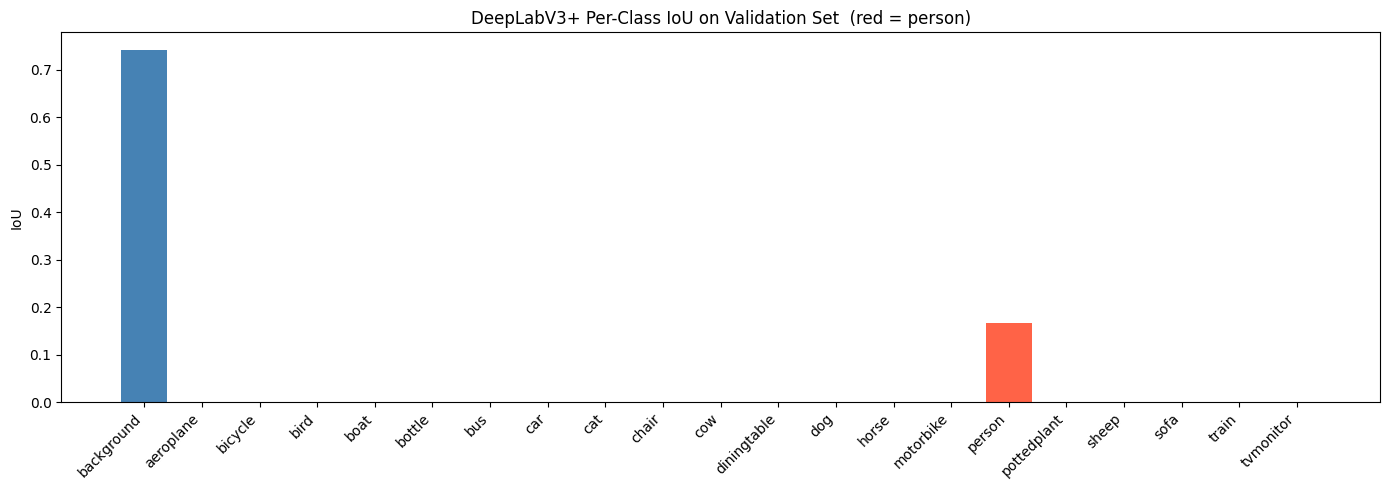

In [39]:
plt.figure(figsize=(14, 5))
iou_values = deeplab_metrics['per_class_iou']
colors = ['tomato' if c == 'person' else 'steelblue' for c in VOC_CLASSES]
plt.bar(VOC_CLASSES, iou_values, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel("IoU")
plt.title("DeepLabV3+ Per-Class IoU on Validation Set  (red = person)")
plt.tight_layout()
plt.show()

# 10. Results Summary Table

Summary table across all 4 models with person-class IoU highlighted, saved to CSV

In [40]:
# Load all metrics (from memory or Drive)
def load_or_use(metrics_dict, hd95_val, path):
    if metrics_dict is not None:
        return metrics_dict, hd95_val
    with open(path) as f:
        saved = json.load(f)
    return saved, saved['hd95']

rows = []
model_configs = [
    ("U-Net",              unet_metrics,        unet_hd95,        None),
    ("SAM2 Zero-Shot",     sam_metrics,         sam_hd95,         None),
    ("SAM2 Fine-Tuned",    sam2_ft_metrics,     sam2_ft_hd95,     None),
    ("DeepLabV3+",         deeplab_metrics,     deeplab_hd95,     None),
]

for name, metrics, hd95, _ in model_configs:
    rows.append({
        "Model":        name,
        "Pixel Acc":    f"{metrics['pixel_acc']:.4f}",
        "mIoU":         f"{metrics['mIoU']:.4f}",
        "mDice":        f"{metrics['mDice']:.4f}",
        "HD95":         f"{hd95:.4f}",
        "Person IoU":   f"{metrics['per_class_iou'][VOC_CLASSES.index('person')]:.4f}",
    })

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))

# Save to Drive
summary_path = os.path.join(base_path, 'results_summary.csv')
df_summary.to_csv(summary_path, index=False)
print("\nSummary table saved to:", summary_path)

          Model Pixel Acc   mIoU  mDice     HD95 Person IoU
          U-Net    0.7410 0.0386 0.0467  87.1329     0.0693
 SAM2 Zero-Shot    0.9137 0.6651 0.7704  47.1570     0.7555
SAM2 Fine-Tuned    0.8135 0.1425 0.1987 100.3469     0.6699
     DeepLabV3+    0.7285 0.0433 0.0542  60.4971     0.1663

Summary table saved to: /content/drive/MyDrive/Colab Notebooks/SHBT261_miniproj2/results_summary.csv


# 11. Comparison Plots

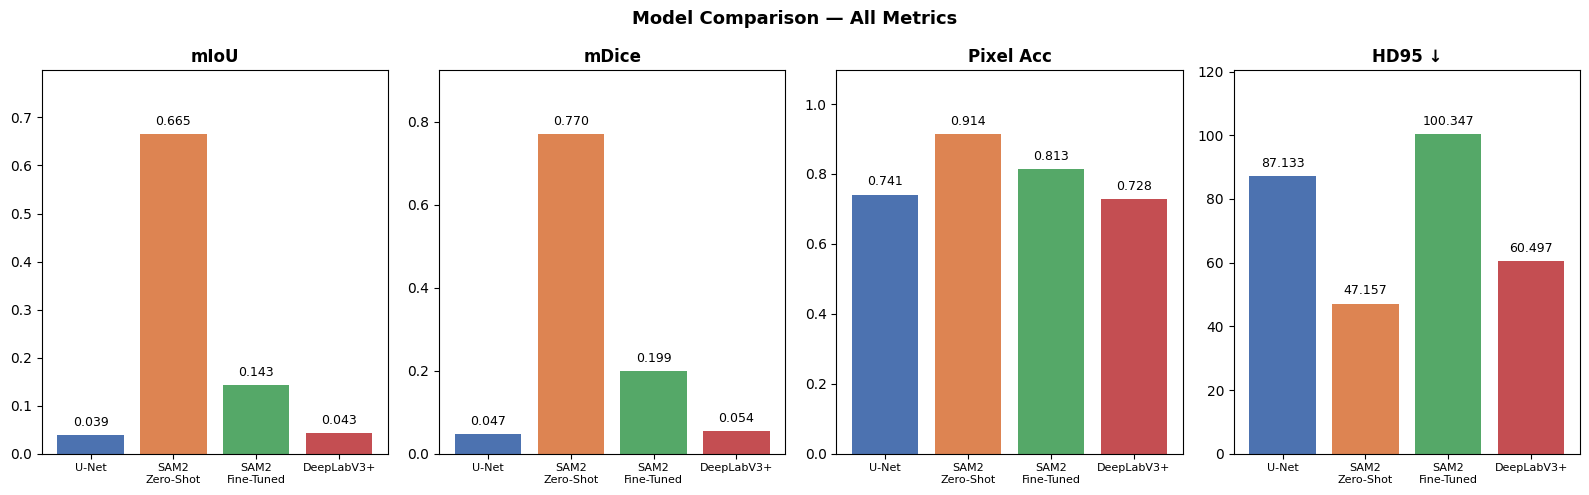

In [41]:
model_names  = ["U-Net", "SAM2\nZero-Shot", "SAM2\nFine-Tuned", "DeepLabV3+"]
all_metrics  = [unet_metrics, sam_metrics, sam2_ft_metrics, deeplab_metrics]
all_hd95     = [unet_hd95,    sam_hd95,    sam2_ft_hd95,    deeplab_hd95]
colors       = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

metrics_to_plot = [
    ('mIoU',       [m['mIoU']       for m in all_metrics]),
    ('mDice',      [m['mDice']      for m in all_metrics]),
    ('Pixel Acc',  [m['pixel_acc']  for m in all_metrics]),
    ('HD95 ↓',     all_hd95),
]

for ax, (title, vals) in zip(axes, metrics_to_plot):
    bars = ax.bar(model_names, vals, color=colors)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'comparison_all_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

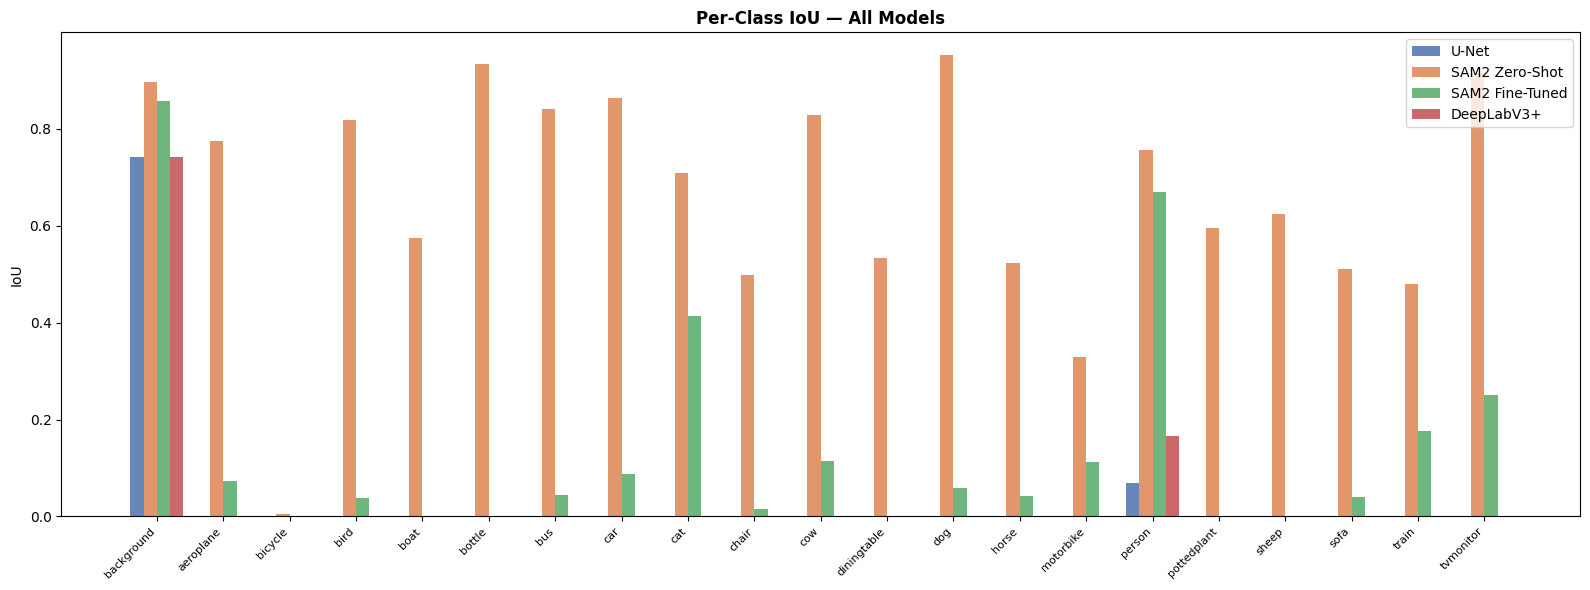

In [42]:
# Per-class IoU comparison across all models
fig, ax = plt.subplots(figsize=(16, 6))
x     = np.arange(len(VOC_CLASSES))
width = 0.2

for i, (name, metrics, color) in enumerate(zip(
        ["U-Net", "SAM2 Zero-Shot", "SAM2 Fine-Tuned", "DeepLabV3+"],
        all_metrics, colors)):
    ax.bar(x + i*width, metrics['per_class_iou'], width, label=name, color=color, alpha=0.85)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(VOC_CLASSES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("IoU")
ax.set_title("Per-Class IoU — All Models", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'comparison_perclass_iou.png'), dpi=150, bbox_inches='tight')
plt.show()

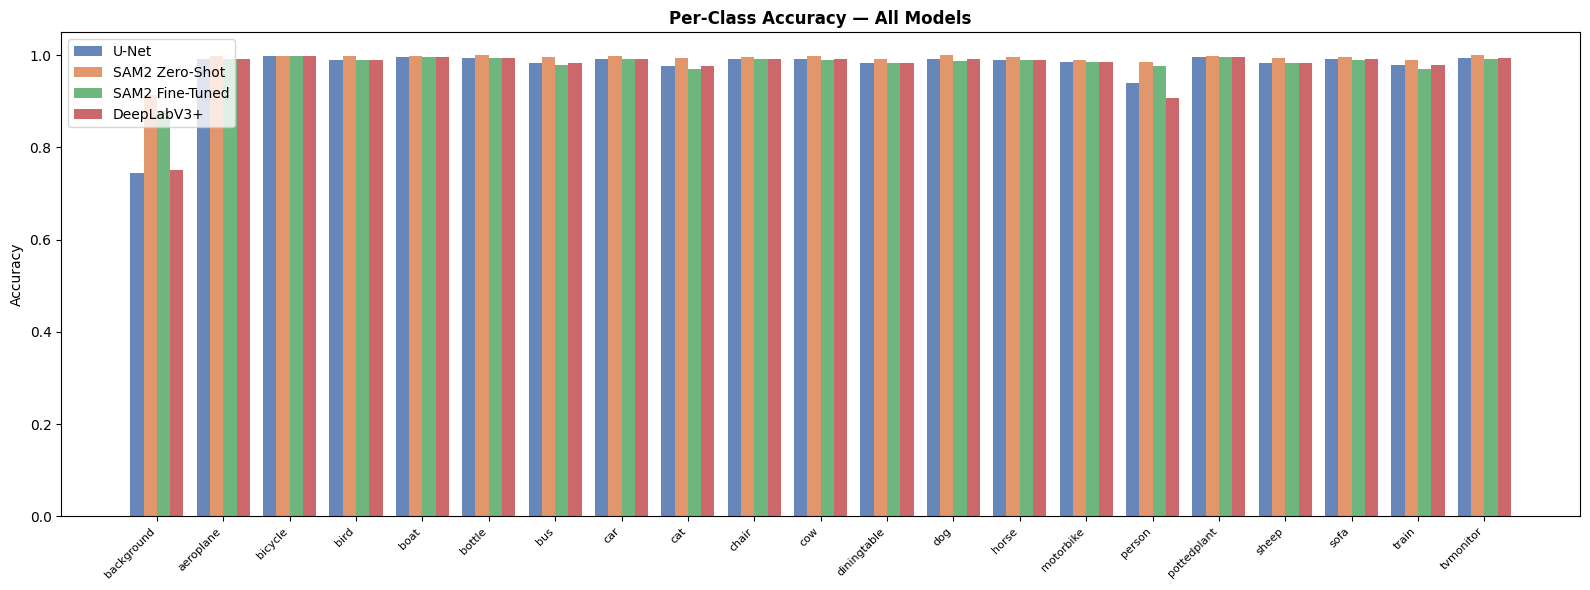

In [43]:
# Per-class Accuracy comparison across all models
fig, ax = plt.subplots(figsize=(16, 6))
x     = np.arange(len(VOC_CLASSES))
width = 0.2

for i, (name, metrics, color) in enumerate(zip(
        ["U-Net", "SAM2 Zero-Shot", "SAM2 Fine-Tuned", "DeepLabV3+"],
        all_metrics, colors)):
    acc_values = [v if not np.isnan(v) else 0.0 for v in metrics['per_class_acc']]
    ax.bar(x + i*width, acc_values, width, label=name, color=color, alpha=0.85)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(VOC_CLASSES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Accuracy")
ax.set_title("Per-Class Accuracy — All Models", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'comparison_perclass_acc.png'), dpi=150, bbox_inches='tight')
plt.show()

# 12. Qualitative Visualizations

Mosaic visualization + top 3 best/worst per model focused on person class, using a reusable plot_mosaic() and get_best_worst_indices() helper

## 12.1 Mosaic: Sample Predictions vs Ground Truth

In [ ]:
def make_color_mask(mask_np, ignore_index=255):
    """Map class indices to RGB colors using tab20 colormap."""
    cmap   = plt.cm.get_cmap('tab20', 21)
    vis    = cmap(mask_np / 20.0)[:, :, :3]   # (H, W, 3)
    vis[mask_np == ignore_index] = 0.5          # grey for boundary
    return (vis * 255).astype(np.uint8)

def plot_mosaic(val_dataset_raw, model_preds_list, model_names, indices, title="Mosaic"):
    """
    Plot a mosaic: rows = selected images, cols = [Image, GT, model1, model2, ...]
    val_dataset_raw : raw VOCSegmentation (no transforms)
    model_preds_list: list of (N,H,W) tensors, one per model
    indices         : list of image indices to show
    """
    n_rows = len(indices)
    n_cols = 2 + len(model_preds_list)   # image + GT + one per model

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(3.5 * n_cols, 3.5 * n_rows))

    col_titles = ["Image", "Ground Truth"] + model_names
    for j, t in enumerate(col_titles):
        axes[0, j].set_title(t, fontsize=10, fontweight='bold')

    for row, idx in enumerate(indices):
        img_pil, mask_pil = val_dataset_raw[idx]
        img_pil_r  = img_pil.convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        mask_pil_r = mask_pil.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
        mask_np    = np.array(mask_pil_r)

        axes[row, 0].imshow(img_pil_r)
        axes[row, 1].imshow(make_color_mask(mask_np))

        for col, preds in enumerate(model_preds_list, start=2):
            axes[row, col].imshow(make_color_mask(preds[idx].numpy()))

        for ax in axes[row]:
            ax.axis('off')

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(base_path, f'{title.replace(" ","_")}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


# Raw val dataset for visualization
val_dataset_raw_vis = VOCSegmentation(
    root=trainval_root, year="2007", image_set="val",
    download=False, transform=None, target_transform=None
)

# Show 5 random samples
np.random.seed(42)
sample_indices = np.random.choice(len(val_dataset_raw_vis), 5, replace=False).tolist()

plot_mosaic(
    val_dataset_raw_vis,
    model_preds_list = [unet_preds, sam_preds, sam2_ft_preds, deeplab_preds],
    model_names      = ["U-Net", "SAM2 ZS", "SAM2 FT", "DeepLabV3+"],
    indices          = sample_indices,
    title            = "Mosaic — Sample Predictions"
)

## 12.2 Top 3 Best & Worst Results per Model (Person Class Focus)

In [ ]:
def get_best_worst_indices(preds, masks, class_idx, n=3):
    """
    Return indices of top-n best and worst predictions for a given class
    based on per-image IoU.
    """
    preds_np = preds.numpy()
    masks_np = masks.numpy()
    ious = []
    for i in range(len(preds_np)):
        pred_bin = (preds_np[i] == class_idx)
        mask_bin = (masks_np[i] == class_idx) & (masks_np[i] != IGNORE_INDEX)
        if mask_bin.sum() == 0:
            ious.append(np.nan)
            continue
        tp = (pred_bin & mask_bin).sum()
        fp = (pred_bin & ~mask_bin).sum()
        fn = (~pred_bin & mask_bin).sum()
        ious.append(tp / (tp + fp + fn + 1e-6))

    ious = np.array(ious)
    valid = np.where(~np.isnan(ious))[0]
    sorted_valid = valid[np.argsort(ious[valid])]
    worst = sorted_valid[:n].tolist()
    best  = sorted_valid[-n:][::-1].tolist()
    return best, worst


PERSON_IDX = VOC_CLASSES.index('person')

model_configs_vis = [
    ("U-Net",           unet_preds,     unet_masks),
    ("SAM2 Zero-Shot",  sam_preds,      sam_gt),
    ("SAM2 Fine-Tuned", sam2_ft_preds,  sam2_ft_masks),
    ("DeepLabV3+",      deeplab_preds,  deeplab_masks),
]

for model_name, preds, masks in model_configs_vis:
    best_idx, worst_idx = get_best_worst_indices(preds, masks, PERSON_IDX, n=3)

    for label, indices in [("Best", best_idx), ("Worst", worst_idx)]:
        plot_mosaic(
            val_dataset_raw_vis,
            model_preds_list = [preds],
            model_names      = [model_name],
            indices          = indices,
            title            = f"{model_name} — Top 3 {label} (Person Class)"
        )

## 12.3 Top 3 Best & Worst — All Models Side-by-Side (Person Class)

In [ ]:
def get_per_image_iou(preds, masks, class_idx):
    """Return per-image IoU array for a given class. NaN if class absent in GT."""
    preds_np = preds.numpy()
    masks_np = masks.numpy()
    ious = []
    for i in range(len(preds_np)):
        pred_bin = (preds_np[i] == class_idx)
        mask_bin = (masks_np[i] == class_idx) & (masks_np[i] != IGNORE_INDEX)
        if mask_bin.sum() == 0:
            ious.append(np.nan)
            continue
        tp = (pred_bin & mask_bin).sum()
        fp = (pred_bin & ~mask_bin).sum()
        fn = (~pred_bin & mask_bin).sum()
        ious.append(tp / (tp + fp + fn + 1e-6))
    return np.array(ious)


# Compute per-image person IoU for each model
iou_unet     = get_per_image_iou(unet_preds,    unet_masks,    PERSON_IDX)
iou_sam_zs   = get_per_image_iou(sam_preds,     sam_gt,        PERSON_IDX)
iou_sam_ft   = get_per_image_iou(sam2_ft_preds, sam2_ft_masks, PERSON_IDX)
iou_deeplab  = get_per_image_iou(deeplab_preds, deeplab_masks, PERSON_IDX)

# Average IoU across all 4 models per image (only images where ALL models have valid GT)
iou_stack = np.stack([iou_unet, iou_sam_zs, iou_sam_ft, iou_deeplab], axis=0)  # (4, N)
mean_iou  = np.nanmean(iou_stack, axis=0)                                        # (N,)

# Only consider images where person class is present in GT
valid_idx = np.where(~np.isnan(mean_iou))[0]
sorted_valid = valid_idx[np.argsort(mean_iou[valid_idx])]

best_indices  = sorted_valid[-3:][::-1].tolist()   # top 3 highest mean IoU
worst_indices = sorted_valid[:3].tolist()           # top 3 lowest mean IoU


def plot_best_worst_all_models(val_dataset_raw, indices, label,
                               preds_list, model_names):
    """
    For each image index, show: Image | GT | UNet | SAM2-ZS | SAM2-FT | DeepLabV3+
    One row per image.
    """
    n_rows = len(indices)
    n_cols = 2 + len(preds_list)   # Image + GT + one per model

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(3.2 * n_cols, 3.2 * n_rows))

    # Column headers
    col_titles = ["Image", "Ground Truth"] + model_names
    for j, t in enumerate(col_titles):
        axes[0, j].set_title(t, fontsize=10, fontweight='bold')

    for row, idx in enumerate(indices):
        img_pil, mask_pil = val_dataset_raw[idx]
        img_pil_r  = img_pil.convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        mask_pil_r = mask_pil.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
        mask_np    = np.array(mask_pil_r)

        # Compute per-model person IoU for this image (for row label)
        row_ious = []
        for preds in preds_list:
            pred_bin = (preds[idx].numpy() == PERSON_IDX)
            mask_bin = (mask_np == PERSON_IDX)
            tp = (pred_bin & mask_bin).sum()
            fp = (pred_bin & ~mask_bin).sum()
            fn = (~pred_bin & mask_bin).sum()
            row_ious.append(tp / (tp + fp + fn + 1e-6))

        # Image
        axes[row, 0].imshow(img_pil_r)
        axes[row, 0].set_ylabel(f"img #{idx}", fontsize=8)

        # Ground truth
        axes[row, 1].imshow(make_color_mask(mask_np))

        # Each model's prediction + IoU annotation
        for col, (preds, iou) in enumerate(zip(preds_list, row_ious), start=2):
            axes[row, col].imshow(make_color_mask(preds[idx].numpy()))
            axes[row, col].set_xlabel(f"Person IoU: {iou:.3f}", fontsize=8)

        for ax in axes[row]:
            ax.axis('off')
        # Re-enable ylabel axis visibility
        axes[row, 0].axis('on')
        axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
        for spine in axes[row, 0].spines.values():
            spine.set_visible(False)

    plt.suptitle(f"Top 3 {label} — All Models Side-by-Side (Person Class)",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(base_path, f'best_worst_{label.lower()}_all_models.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


preds_list   = [unet_preds, sam_preds, sam2_ft_preds, deeplab_preds]
model_names  = ["U-Net", "SAM2 ZS", "SAM2 FT", "DeepLabV3+"]

plot_best_worst_all_models(val_dataset_raw_vis, best_indices,  "Best",
                           preds_list, model_names)
plot_best_worst_all_models(val_dataset_raw_vis, worst_indices, "Worst",
                           preds_list, model_names)